# Apresentação dos resultados - MPI

**Discente: Igor Sousa dos Santos Santana**
<br>
**Docente: Esbel Tomás Valero Orellana**
<br>
**Disciplina: Processamento Paralelo**
<br>

## A proposta

Este trabalho propõe o desenvolvimento e a análise de desempenho de um algoritmo para o cálculo de *Bounding Box* aplicado a conjuntos de dados multidimensionais. A implementação é realizada integralmente na linguagem C, focando em eficiência, paralelismo baseado em troca de mensagens e controle de baixo nível sobre a memória e a comunicação entre processos.

### Objetivos Principais:

- **Estrutura de Dados Customizada:** Para gerenciar os dados de entrada, foi implementada uma estrutura chamada Tensor, que encapsula o ponteiro de dados e as informações de dimensionalidade, permitindo uma manipulação robusta de volumes de dados médicos ou científicos.
- **Implementação Sequencial:** Desenvolvimento de uma versão de referência executada em um único processo, garantindo a corretude do cálculo dos limites espaciais da região de interesse.
- **Implementação Paralela com MPI:** Integração da biblioteca MPI, Message Passing Interface, para particionar os dados e distribuir a carga de processamento entre múltiplos processos independentes, visando reduzir o tempo de execução em grandes volumes de dados.
    - Os testes computacionais foram realizados utilizando uma configuração estável de 16 processos paralelos;
    - O ambiente de execução consistiu em uma máquina dedicada de 16 núcleos físicos, permitindo o mapeamento nativo de um processo por núcleo da CPU;
    - Para a análise dos resultados deste trabalho, foram consolidados os dados de tempo e desempenho obtidos estritamente sob essa arquitetura de 16 processos.

### Estudo de Escalabilidade e Estratégias com MPI:

O foco central é a comparação entre diferentes estratégias de particionamento de dados e troca de mensagens fornecidas pela biblioteca MPI. O objetivo é identificar qual abordagem de distribuição de subvolumes e consolidação de resultados melhor se adapta à carga de trabalho do algoritmo de *Bounding Box* sobre a estrutura de *Tensor*. Estão sendo avaliadas as seguintes abordagens:
- **Sequencial:** Sem paralelismo (execução isolada no processo principal);
- **Distribuição Estática por Blocos:** Divisão contígua, fixa e uniforme das dimensões do Tensor entre os 16 processos no início da execução, minimizando o overhead de comunicação;
- **Distribuição Dinâmica (Mestre-Escravo):** Alocação sob demanda de blocos do *Tensor* para os processos trabalhadores conforme eles concluem suas tarefas, estratégia ideal para mitigar o desbalanceamento de carga na busca por limites espaciais;
- **Sincronização por Comunicação Coletiva:** Utilização de rotinas coletivas otimizadas (como MPI_Scatter para a distribuição inicial e MPI_Reduce para a redução das coordenadas locais) para consolidar as Bounding Boxes parciais em um limite global de forma eficiente, reduzindo o custo de sincronização.

Ao final desta análise, os resultados de tempo de execução, speedup e eficiência distribuída serão confrontados para determinar a melhor configuração de processamento paralelo e topologia de comunicação para a estrutura de *Tensor* proposta.

## Implementação

Nesse capítulos serão apresentados os códigos fonte (cabeçalho e implementação) utilizados para gerar os dados explorados nesse trabalho.

### Implementação de funções utilitárias

#### Cabeçalho

```c
#ifndef CONFIG_H
#define CONFIG_H

#include <locale.h>

#define endl "\n"

void configuration();

#endif
```

#### Implementação

```c
#include <locale.h>
#include "../lib/config.h"

void configuration() {
    setlocale(LC_ALL, "Portuguese");
}
```

### Implementação do Tensor

#### Cabeçalho

```c
#ifndef TENSOR_H
#define TENSOR_H

#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>

typedef struct tensor {
    double *data;
    size_t x;
    size_t y;
    size_t z;
} Ttensor;

void build_tensor_from_file(FILE *file, Ttensor *ptr_tensor);
void destroy_tensor_data(Ttensor *ptr_tensor);
void allocate_array(Ttensor *ptr_tensor, size_t data_size);

#endif
```

#### Implementação

```c
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>
#include "../lib/tensor.h"

void build_tensor_from_file(FILE *file, Ttensor *ptr_tensor) {
    size_t array_size;

    fscanf(file, "%lu", &ptr_tensor->x);
    fscanf(file, "%lu", &ptr_tensor->y);
    fscanf(file, "%lu", &ptr_tensor->z);
    array_size = ptr_tensor->x * ptr_tensor->y * ptr_tensor->z;
    allocate_array(ptr_tensor, array_size);

    for(size_t i = 0; i < array_size; i++) {
        fscanf(file, "%lf", (ptr_tensor->data + i));
    }

    return;
}

void destroy_tensor_data(Ttensor *ptr_tensor) {
    free(ptr_tensor->data);

    return;
}

void allocate_array(Ttensor *ptr_tensor, size_t data_size) {
    ptr_tensor->data = (double*) malloc(data_size * sizeof(double));
    
    if(ptr_tensor->data == NULL) {
        printf("Could not allocate enough space to save tensor data.\n");
        exit(-1);
    }

    return;
}
```

### Implementação sequencial

```c
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>
#include <stdint.h>
#include <string.h>
#include <time.h>
#include "../lib/config.h"
#include "../lib/tensor.h"

typedef struct coordinates {
    size_t x_begin;
    size_t x_end;
    size_t y_begin;
    size_t y_end;
    size_t z_begin;
    size_t z_end;
} Tcoordinates;

void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD);
void get_indices_with_padding(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates);
void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor);

int main(const int argc, const char *argv[]) {
    FILE *input_file,
        *output_file;
    Ttensor tensor,
        croped_tensor;
    float threshold;
    const char *filename;
    clock_t start,
        global_start = clock();

    if(argc > 2) {
        filename = argv[1];
        threshold = atof(argv[2]);
    } else {
        filename = " ";
        threshold = 0.5;
    }

    configuration();
    input_file = fopen(filename, "r");


    if(input_file == NULL) {
        printf("Could not find file *%s*" endl, filename);
        exit(-1);
    }

    start = clock();
    printf("Reading data from input file..." endl);
    build_tensor_from_file(input_file, &tensor);
    printf("Read time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);
    fclose(input_file);
    start = clock();

    printf("Running bounding box..." endl);
    binarize_data(&tensor, threshold);

    crop_data(&tensor, &croped_tensor);
    printf("Process time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);

    output_file = fopen("output_sequential.txt", "w");

    if(output_file == NULL) {
        printf("Could not find output file." endl);
        exit(-1);
    }

    printf("Writing data to output file..." endl);
    start = clock();

    for(size_t k = 0; k < croped_tensor.z; k++) {
        for(size_t i = 0; i < croped_tensor.x; i++) {
            for(size_t j = 0; j < croped_tensor.y; j++) {
                size_t input_index = (i * croped_tensor.y * croped_tensor.z) + (j * croped_tensor.z) + k;

                fprintf(output_file, "%lf\t", croped_tensor.data[input_index]);
            }

            fprintf(output_file, endl);
        }

        fprintf(output_file, endl "---- ---- ----" endl endl);
    }

    printf("Write time: %lf" endl, (double) (clock() - start) / CLOCKS_PER_SEC);
    fclose(output_file);
    destroy_tensor_data(&tensor);
    destroy_tensor_data(&croped_tensor);
    printf("Total time: %lf" endl, (double) (clock() - global_start) / CLOCKS_PER_SEC);
    return 0;
}

void binarize_data(Ttensor *ptr_tensor, const float THRESHOLD) {
    for(size_t k = 0; k < ptr_tensor->z; k++) {
        for(size_t i = 0; i < ptr_tensor->x; i++) {
            for(size_t j = 0; j < ptr_tensor->y; j++) {
                size_t index = (i * ptr_tensor->y * ptr_tensor->z) + (j * ptr_tensor->z) + k;

                ptr_tensor->data[index] = (ptr_tensor->data[index] > THRESHOLD)? 1.0 : 0.0;
            }
        }
    }

    return;
}

void get_indices_with_padding(const Ttensor *ptr_tensor, Tcoordinates *ptr_coordinates) {
    size_t x_min = ptr_tensor->x,
        y_min = ptr_tensor->y,
        z_min = ptr_tensor->z,
        x_max = 0,
        y_max = 0,
        z_max = 0;

    for(size_t k = 0; k < ptr_tensor->z; k++) {
        for(size_t i = 0; i < ptr_tensor->x; i++) {
            for(size_t j = 0; j < ptr_tensor->y; j++) {
                size_t index = (i * ptr_tensor->y * ptr_tensor->z) + (j * ptr_tensor->z) + k;

                if(ptr_tensor->data[index]) {
                    if(i < x_min) {
                        x_min = i;
                    }

                    if(j < y_min) {
                        y_min = j;
                    }

                    if(k < z_min) {
                        z_min = k;
                    }

                    if(i > x_max) {
                        x_max = i;
                    }

                    if(j > y_max) {
                        y_max = j;
                    }

                    if(k > z_max) {
                        z_max = k;
                    }
                }
            }
        }
    }

    ptr_coordinates->x_begin = (x_min > 5) ? x_min - 5 : 0;
    ptr_coordinates->y_begin = (y_min > 5) ? y_min - 5 : 0;
    ptr_coordinates->z_begin = (z_min > 5) ? z_min - 5 : 0;
    ptr_coordinates->x_end = (x_max + 5 < ptr_tensor->x) ? x_max + 5 : ptr_tensor->x - 1;
    ptr_coordinates->y_end = (y_max + 5 < ptr_tensor->y) ? y_max + 5 : ptr_tensor->y - 1;
    ptr_coordinates->z_end = (z_max + 5 < ptr_tensor->z) ? z_max + 5 : ptr_tensor->z - 1;
    return;
}

void crop_data(const Ttensor *ptr_input_tensor, Ttensor *ptr_output_tensor) {
    Tcoordinates coordinates;
    size_t slice_size = 0,
        output_index = 0,
        total_elements;

    get_indices_with_padding(ptr_input_tensor, &coordinates);

    if(coordinates.x_end < coordinates.x_begin) {
        printf("Error: No data was found." endl);
        exit(-1);
    }

    ptr_output_tensor->x = coordinates.x_end - coordinates.x_begin + 1;
    ptr_output_tensor->y = coordinates.y_end - coordinates.y_begin + 1;
    ptr_output_tensor->z = coordinates.z_end - coordinates.z_begin + 1;
    total_elements = ptr_output_tensor->x * ptr_output_tensor->y * ptr_output_tensor->z;

    allocate_array(ptr_output_tensor, total_elements); 

    slice_size = ptr_output_tensor->z * sizeof(double);

    for(size_t i = coordinates.x_begin; i <= coordinates.x_end; i++) {
        for(size_t j = coordinates.y_begin; j <= coordinates.y_end; j++) {
            size_t input_index = (i * ptr_input_tensor->y * ptr_input_tensor->z) + \
                                (j * ptr_input_tensor->z) + coordinates.z_begin;

            memcpy(&ptr_output_tensor->data[output_index], &ptr_input_tensor->data[input_index], slice_size);
            output_index += ptr_output_tensor->z;
        }
    }

    return;
}
```

### Implementação paralela com MPI

```c
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>
#include <stddef.h>
#include <float.h>
#include <string.h>
#include <mpi.h>
#include "../lib/config.h"
#include "../lib/tensor.h"

typedef struct coordinates {
    size_t x_begin;
    size_t x_end;
    size_t y_begin;
    size_t y_end;
    size_t z_begin;
    size_t z_end;
} Tcoordinates;

void binarize_data(Ttensor *ptr_local_tensor, const float THRESHOLD);
void get_indices_with_padding(const Ttensor *ptr_local_tensor, const size_t rank_local_offset_X, const size_t global_X, Tcoordinates *ptr_coordinates);
void crop_data(const Ttensor *ptr_local_tensor, const size_t rank_local_offset_X, const Tcoordinates *ptr_coordinates, Ttensor *ptr_output_tensor);

int main(int argc, char *argv[]) {
    int rank,
        size;

    MPI_Init(&argc, &argv);
    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);

    FILE *input_file = NULL,
        *output_file = NULL;
    Ttensor global_tensor,
        local_tensor,
        cropped_tensor;
    float threshold;
    const char *filename;
    double start_time,
        global_start_time;
    size_t dims[3],
        global_X,
        global_Y,
        global_Z,
        local_X_base,
        rest,
        rank_local_X,
        rank_local_offset_X;
    int *elements_per_rank = NULL,
        *buffer_displacement = NULL;
    Tcoordinates global_coordinates;

    global_start_time = MPI_Wtime();

    if(argc > 2) {
        filename = argv[1];
        threshold = atof(argv[2]);
    } else {
        filename = " ";
        threshold = 0.5;
    }

    if(rank == 0) {
        configuration();
        input_file = fopen(filename, "r");

        if(input_file == NULL) {
            printf("Could not find file *%s*" endl, filename);
            MPI_Abort(MPI_COMM_WORLD, -1);
            exit(-1);
        }

        printf("Reading data from input file..." endl);
        start_time = MPI_Wtime();
        build_tensor_from_file(input_file, &global_tensor);
        printf("Read time: %lf\n", MPI_Wtime() - start_time);
        fclose(input_file);
    }

    if(rank == 0) {
        dims[0] = global_tensor.x;
        dims[1] = global_tensor.y;
        dims[2] = global_tensor.z;
    }

    MPI_Bcast(dims, 3, MPI_UNSIGNED_LONG, 0, MPI_COMM_WORLD);
    global_X = dims[0];
    global_Y = dims[1];
    global_Z = dims[2];

    local_X_base = global_X / size;
    rest = global_X % size;
    rank_local_X = local_X_base + (rank < rest ? 1 : 0);
    rank_local_offset_X = rank * local_X_base + (rank < rest ? rank : rest);

    local_tensor.x = rank_local_X;
    local_tensor.y = global_Y;
    local_tensor.z = global_Z;
    allocate_array(&local_tensor, rank_local_X * global_Y * global_Z);

    if(rank == 0) {
        elements_per_rank = malloc(size * sizeof(int));
        buffer_displacement = malloc(size * sizeof(int));
        int sum_of_displacements = 0;

        for(int current_rank = 0; current_rank < size; current_rank++) {
            size_t rank_X = local_X_base + ((current_rank < rest) ? 1 : 0);

            elements_per_rank[current_rank] = (int) (rank_X * global_Y * global_Z);
            buffer_displacement[current_rank] = sum_of_displacements;
            sum_of_displacements += elements_per_rank[current_rank];
        }
    }

    MPI_Scatterv(
        rank == 0 ? global_tensor.data : NULL,
        elements_per_rank,
        buffer_displacement,
        MPI_DOUBLE,
        local_tensor.data,
        rank_local_X * global_Y * global_Z,
        MPI_DOUBLE,
        0,
        MPI_COMM_WORLD
    );

    if(rank == 0) {
        free(elements_per_rank);
        free(buffer_displacement);
        printf("Running operations in parallel via MPI..." endl);
    }

    start_time = MPI_Wtime();
    binarize_data(&local_tensor, threshold);
    get_indices_with_padding(
        &local_tensor,
        rank_local_offset_X,
        global_X,
        &global_coordinates
    );
    crop_data(
        &local_tensor,
        rank_local_offset_X,
        &global_coordinates,
        &cropped_tensor
    );

    if(rank == 0) {
        printf("Process time: %lf\n", MPI_Wtime() - start_time);
        output_file = fopen("output_MPI.txt", "w");

        if(output_file == NULL) {
            printf("Could not find output file." endl);
            MPI_Abort(MPI_COMM_WORLD, -1);
            exit(-1);
        }

        printf("Writing data to output file..." endl);
        start_time = MPI_Wtime();

        for(size_t k = 0; k < cropped_tensor.z; k++) {
            for(size_t i = 0; i < cropped_tensor.x; i++) {
                for(size_t j = 0; j < cropped_tensor.y; j++) {
                    size_t input_index = (i * cropped_tensor.y * cropped_tensor.z) + (j * cropped_tensor.z) + k;

                    fprintf(output_file, "%lf\t", cropped_tensor.data[input_index]);
                }

                fprintf(output_file, "\n");
            }

            fprintf(output_file, endl "---- ---- ----" endl endl);
        }

        printf("Write time: %lf" endl, MPI_Wtime() - start_time);
        fclose(output_file);
        
        destroy_tensor_data(&global_tensor);
        destroy_tensor_data(&cropped_tensor);
        printf("Total time: %lf" endl, MPI_Wtime() - global_start_time);
    }

    destroy_tensor_data(&local_tensor);
    MPI_Finalize();
    return 0;
}

void binarize_data(Ttensor *ptr_local_tensor, const float THRESHOLD) {
    for(size_t k = 0; k < ptr_local_tensor->z; k++) {
        for(size_t i = 0; i < ptr_local_tensor->x; i++) {
            for(size_t j = 0; j < ptr_local_tensor->y; j++) {
                size_t index = (i * ptr_local_tensor->y * ptr_local_tensor->z) + (j * ptr_local_tensor->z) + k;

                ptr_local_tensor->data[index] = (ptr_local_tensor->data[index] > THRESHOLD) ? 1.0 : 0.0;
            }
        }
    }

    return;
}

void get_indices_with_padding(const Ttensor *ptr_local_tensor, const size_t rank_local_offset_X, const size_t global_X, Tcoordinates *ptr_coordinates) {
    size_t x_min_local = global_X,
        y_min_local = ptr_local_tensor->y,
        z_min_local = ptr_local_tensor->z,
        x_max_local = 0,
        y_max_local = 0,
        z_max_local = 0,
        x_min_global,
        y_min_global,
        z_min_global,
        x_max_global,
        y_max_global,
        z_max_global;

    for(size_t k = 0; k < ptr_local_tensor->z; k++) {
        for(size_t i = 0; i < ptr_local_tensor->x; i++) {
            for(size_t j = 0; j < ptr_local_tensor->y; j++) {
                size_t index = (i * ptr_local_tensor->y * ptr_local_tensor->z) + (j * ptr_local_tensor->z) + k;

                if(ptr_local_tensor->data[index]) {
                    size_t global_index = i + rank_local_offset_X;

                    if(global_index < x_min_local) {
                        x_min_local = global_index;
                    }

                    if(j < y_min_local) {
                        y_min_local = j;
                    }

                    if(k < z_min_local) {
                        z_min_local = k;
                    }

                    if(global_index > x_max_local) {
                        x_max_local = global_index;
                    }

                    if(j > y_max_local) {
                        y_max_local = j;
                    }

                    if(k > z_max_local) {
                        z_max_local = k;
                    }
                }
            }
        }
    }

    MPI_Allreduce(&x_min_local, &x_min_global, 1, MPI_UNSIGNED_LONG, MPI_MIN, MPI_COMM_WORLD);
    MPI_Allreduce(&y_min_local, &y_min_global, 1, MPI_UNSIGNED_LONG, MPI_MIN, MPI_COMM_WORLD);
    MPI_Allreduce(&z_min_local, &z_min_global, 1, MPI_UNSIGNED_LONG, MPI_MIN, MPI_COMM_WORLD);

    MPI_Allreduce(&x_max_local, &x_max_global, 1, MPI_UNSIGNED_LONG, MPI_MAX, MPI_COMM_WORLD);
    MPI_Allreduce(&y_max_local, &y_max_global, 1, MPI_UNSIGNED_LONG, MPI_MAX, MPI_COMM_WORLD);
    MPI_Allreduce(&z_max_local, &z_max_global, 1, MPI_UNSIGNED_LONG, MPI_MAX, MPI_COMM_WORLD);

    ptr_coordinates->x_begin = (x_min_global > 5) ? x_min_global - 5 : 0;
    ptr_coordinates->y_begin = (y_min_global > 5) ? y_min_global - 5 : 0;
    ptr_coordinates->z_begin = (z_min_global > 5) ? z_min_global - 5 : 0;
    ptr_coordinates->x_end = (x_max_global + 5 < global_X) ? x_max_global + 5 : global_X - 1;
    ptr_coordinates->y_end = (y_max_global + 5 < ptr_local_tensor->y) ? y_max_global + 5 : ptr_local_tensor->y - 1;
    ptr_coordinates->z_end = (z_max_global + 5 < ptr_local_tensor->z) ? z_max_global + 5 : ptr_local_tensor->z - 1;
    return;
}

void crop_data(const Ttensor *ptr_local_tensor, const size_t rank_local_offset_X, const Tcoordinates *ptr_coordinates, Ttensor *ptr_output_tensor) {
    int rank,
        size;

    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &size);
    
    int local_count,
        *recvcounts = NULL,
        *displacements = NULL;
    double *local_crop_data = NULL;
    size_t output_x = ptr_coordinates->x_end - ptr_coordinates->x_begin + 1,
        output_y = ptr_coordinates->y_end - ptr_coordinates->y_begin + 1,
        output_z = ptr_coordinates->z_end - ptr_coordinates->z_begin + 1,
        global_start_index,
        global_end_index,
        num_local_crop_slices,
        local_crop_elements,
        local_output_index = 0,
        slice_size;

    global_start_index = (ptr_coordinates->x_begin > rank_local_offset_X) ? ptr_coordinates->x_begin : rank_local_offset_X;
    global_end_index = (ptr_coordinates->x_end < rank_local_offset_X + ptr_local_tensor->x - 1) ? ptr_coordinates->x_end : (rank_local_offset_X + ptr_local_tensor->x - 1);
    num_local_crop_slices = (global_start_index <= global_end_index) ? (global_end_index - global_start_index + 1) : 0;
    local_crop_elements = num_local_crop_slices * output_y * output_z;

    if(local_crop_elements > 0) {
        local_crop_data = malloc(local_crop_elements * sizeof(double));
    }

    slice_size = output_z * sizeof(double);

    if(num_local_crop_slices > 0) {
        size_t local_start_index = global_start_index - rank_local_offset_X,
            local_end_index = global_end_index - rank_local_offset_X;

        for(size_t i = local_start_index; i <= local_end_index; i++) {
            for(size_t j = ptr_coordinates->y_begin; j <= ptr_coordinates->y_end; j++) {
                size_t input_index = (i * ptr_local_tensor->y * ptr_local_tensor->z) + \
                                    (j * ptr_local_tensor->z) + ptr_coordinates->z_begin;

                memcpy(&local_crop_data[local_output_index], &ptr_local_tensor->data[input_index], slice_size);
                local_output_index += output_z;
            }
        }
    }

    local_count = (int) local_crop_elements;

    if(rank == 0) {
        recvcounts = malloc(size * sizeof(int));
        displacements = malloc(size * sizeof(int));
    }

    MPI_Gather(
        &local_count,
        1,
        MPI_INT,
        recvcounts,
        1,
        MPI_INT,
        0,
        MPI_COMM_WORLD
    );

    if(rank == 0) {
        int sum_of_displacements = 0;

        ptr_output_tensor->x = output_x;
        ptr_output_tensor->y = output_y;
        ptr_output_tensor->z = output_z;
        allocate_array(ptr_output_tensor, output_x * output_y * output_z);

        for(int current_rank = 0; current_rank < size; current_rank++) {
            displacements[current_rank] = sum_of_displacements;
            sum_of_displacements += recvcounts[current_rank];
        }
    }

    MPI_Gatherv(
        local_crop_data,
        local_count,
        MPI_DOUBLE,
        rank == 0 ? ptr_output_tensor->data : NULL,
        recvcounts,
        displacements,
        MPI_DOUBLE,
        0,
        MPI_COMM_WORLD
    );

    if(local_crop_data != NULL) {
        free(local_crop_data);
    }

    if(rank == 0) {
        free(recvcounts);
        free(displacements);
    }

    return;
}
```

## Importando pacotes

A baixo estão os pacotes utilizados para manipulação dos dados e construção dos gráficos

In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Configurando os pacotes de construção de gráficos

In [2]:
sns.set_theme(style="whitegrid")

## Recuperando dataset

In [3]:
result_data_path: str = "data/results_MPI.csv"
results_df: pd.DataFrame = pd.read_csv(result_data_path)

## Testes

Nesse capítulo serão realizados pré-processamento dos dados, separação dos dados em *datasets* separados específicos e análise isolada dos dados.

### Pré-processamento

Nesse subcapítulo serão realizadas transformações nos dados para melhor interpretação e manipulação dos *datasets*.

Os dados originais estão dispostos na forma abaixo:

In [4]:
results_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max
0,1,9.736030,9.736030,0.5,sequencial,NaN,NaN,NaN
1,2,9.643935,9.643935,0.5,sequencial,NaN,NaN,NaN
2,3,9.603937,9.603937,0.5,sequencial,NaN,NaN,NaN
3,4,9.587112,9.587112,0.5,sequencial,NaN,NaN,NaN
4,5,9.576417,9.576417,0.5,sequencial,NaN,NaN,NaN
5,6,5.820079,5.820079,0.5,sequencial,NaN,NaN,NaN
6,7,5.733536,5.733536,0.5,sequencial,NaN,NaN,NaN
7,1,0.891998,0.892713,0.5,MPI,2.0,1.000401,0.000801
8,2,0.883079,0.883325,0.5,MPI,2.0,1.000139,0.000278
9,3,0.883060,0.883465,0.5,MPI,2.0,1.000229,0.000458


Verificando os valores não repetidos da coluna `nome_modo`.

In [5]:
results_df["nome_modo"].unique()

<StringArray>
['sequencial', 'MPI']
Length: 2, dtype: str

Verificando os valores não repetidos da coluna `valor_modo`.

In [6]:
results_df["valor_modo"].unique()

array([nan,  2.,  4.,  8., 16.])

Removendo os valores *NaN* da coluna `valor_modo` e inserindo valores numéricos no lugar.
<br>
Transformando os dados das colunas `nome_modo` e `valor_modo` para valores categóricos.
<br>
Transformando os dados da coluna `interacao` para valores de números inteiros.
<br>
Transformando os dados da coluna `tempo`, `threshold` e `Fab` para valores de números de ponto flutuante.

In [7]:
results_df["valor_modo"].isna().sum()

7

In [8]:
results_df["Fab"].isna().sum()

7

In [9]:
results_df["interacao"] = results_df["interacao"].astype(np.uint8)
results_df["tempo_min"] = results_df["tempo_min"].astype(np.float32)
results_df["tempo_max"] = results_df["tempo_max"].astype(np.float32)
results_df["threshold"] = results_df["threshold"].astype(np.float32)
results_df["nome_modo"] = results_df["nome_modo"].astype("category")
results_df["valor_modo"] = results_df["valor_modo"].fillna(0).astype(np.uint8)
results_df["valor_modo"] = results_df["valor_modo"].astype("category")
results_df["Fab"] = results_df["Fab"].fillna(1.0).astype(np.float64)
results_df["disparidade_min_max"] = results_df["disparidade_min_max"].fillna(0.0).astype(np.float64)
results_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max
0,1,9.736030,9.736030,0.5,sequencial,0,1.000000,0.000000
1,2,9.643935,9.643935,0.5,sequencial,0,1.000000,0.000000
2,3,9.603937,9.603937,0.5,sequencial,0,1.000000,0.000000
3,4,9.587112,9.587112,0.5,sequencial,0,1.000000,0.000000
4,5,9.576417,9.576417,0.5,sequencial,0,1.000000,0.000000
5,6,5.820079,5.820079,0.5,sequencial,0,1.000000,0.000000
6,7,5.733536,5.733536,0.5,sequencial,0,1.000000,0.000000
7,1,0.891998,0.892713,0.5,MPI,2,1.000401,0.000801
8,2,0.883079,0.883325,0.5,MPI,2,1.000139,0.000278
9,3,0.883060,0.883465,0.5,MPI,2,1.000229,0.000458


#### Cálculo de *speed-up*

In [10]:
speed_up: list[np.ndarray[np.float32]] = []

# SEQUENCIAL
speed_up.append(np.array([0] * 7, dtype=np.float32))

# MPI
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "tempo_max"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "tempo_max"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "tempo_max"].values)
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "tempo_max"].values)

# UNINDO TUDO
results_df["speed_up_max"] = np.concatenate(speed_up)
del speed_up

# VERIFICANDO
results_df.head(15)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max
0,1,9.736030,9.736030,0.5,sequencial,0,1.000000,0.000000,0.000000
1,2,9.643935,9.643935,0.5,sequencial,0,1.000000,0.000000,0.000000
2,3,9.603937,9.603937,0.5,sequencial,0,1.000000,0.000000,0.000000
3,4,9.587112,9.587112,0.5,sequencial,0,1.000000,0.000000,0.000000
4,5,9.576417,9.576417,0.5,sequencial,0,1.000000,0.000000,0.000000
5,6,5.820079,5.820079,0.5,sequencial,0,1.000000,0.000000,0.000000
6,7,5.733536,5.733536,0.5,sequencial,0,1.000000,0.000000,0.000000
7,1,0.891998,0.892713,0.5,MPI,2,1.000401,0.000801,10.906114
8,2,0.883079,0.883325,0.5,MPI,2,1.000139,0.000278,10.917766
9,3,0.883060,0.883465,0.5,MPI,2,1.000229,0.000458,10.870762


In [11]:
speed_up: list[np.ndarray[np.float32]] = []

# SEQUENCIAL
speed_up.append(np.array([0] * 7, dtype=np.float32))

# MPI
## 2 processos
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "tempo_min"].values)
## 4 processos
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "tempo_min"].values)
## 8 processos
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "tempo_min"].values)
## 16 processos
speed_up.append(results_df.loc[results_df["nome_modo"] == "sequencial", "tempo_max"].values / results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "tempo_min"].values)

# UNINDO TUDO
results_df["speed_up_min"] = np.concatenate(speed_up)
del speed_up

# VERIFICANDO
results_df.head(15)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min
0,1,9.736030,9.736030,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
1,2,9.643935,9.643935,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
2,3,9.603937,9.603937,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
3,4,9.587112,9.587112,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
4,5,9.576417,9.576417,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
5,6,5.820079,5.820079,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
6,7,5.733536,5.733536,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000
7,1,0.891998,0.892713,0.5,MPI,2,1.000401,0.000801,10.906114,10.914856
8,2,0.883079,0.883325,0.5,MPI,2,1.000139,0.000278,10.917766,10.920807
9,3,0.883060,0.883465,0.5,MPI,2,1.000229,0.000458,10.870762,10.875748


#### Cálculo de eficiência

In [12]:
number_of_processes: list[int] = [2, 4, 8, 16]

# sequencial
results_df.loc[(results_df["nome_modo"] == "sequencial"), "eficiencia_max"] = [1.0] * 7
results_df.loc[(results_df["nome_modo"] == "sequencial"), "eficiencia_min"] = [1.0] * 7
# 2 processos
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "eficiencia_max"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "speed_up_max"] / number_of_processes[0]
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "eficiencia_min"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 2), "speed_up_min"] / number_of_processes[0]
# 4 processos
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "eficiencia_max"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "speed_up_max"] / number_of_processes[1]
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "eficiencia_min"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 4), "speed_up_min"] / number_of_processes[1]
# 8 processos
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "eficiencia_max"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "speed_up_max"] / number_of_processes[2]
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "eficiencia_min"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 8), "speed_up_min"] / number_of_processes[2]
# 16 processos
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "eficiencia_max"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "speed_up_max"] / number_of_processes[3]
results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "eficiencia_min"] = results_df.loc[(results_df["nome_modo"] == "MPI") & (results_df["valor_modo"] == 16), "speed_up_min"] / number_of_processes[3]
del number_of_processes

# VERIFICANDO
results_df.head(15)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
0,1,9.736030,9.736030,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
1,2,9.643935,9.643935,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
2,3,9.603937,9.603937,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
3,4,9.587112,9.587112,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
4,5,9.576417,9.576417,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
5,6,5.820079,5.820079,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
6,7,5.733536,5.733536,0.5,sequencial,0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
7,1,0.891998,0.892713,0.5,MPI,2,1.000401,0.000801,10.906114,10.914856,5.453057,5.457428
8,2,0.883079,0.883325,0.5,MPI,2,1.000139,0.000278,10.917766,10.920807,5.458883,5.460403
9,3,0.883060,0.883465,0.5,MPI,2,1.000229,0.000458,10.870762,10.875748,5.435381,5.437874


### Visualização dos dados

Nesse capítulo serão abordadas as visualizações dos dados adquiridos a partir da execução dos algoritmos sequencial e paralelo (MPI).
<br>
As implementações paralelas com MPI foram feitas para 16 processos em um processador com 16 núcleos.

#### Sequencial

Nesse subcapítulo serão visualizados os dados da implementação sequencial.

In [13]:
sequencial_df: pd.DataFrame = results_df[results_df["nome_modo"] == "sequencial"]
sequencial_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
0,1,9.736030,9.736030,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
1,2,9.643935,9.643935,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
2,3,9.603937,9.603937,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
3,4,9.587112,9.587112,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
4,5,9.576417,9.576417,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
5,6,5.820079,5.820079,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0
6,7,5.733536,5.733536,0.5,sequencial,0,1.0,0.0,0.0,0.0,1.0,1.0


##### Tempo de execução

In [14]:
print("TEMPO")
print("Média:", sequencial_df["tempo_max"].mean())
print("Desvio padrão:", sequencial_df["tempo_max"].std())
print("Valor mínimo:", sequencial_df["tempo_max"].min())
print("Valor máximo:", sequencial_df["tempo_max"].max())

TEMPO
Média: 8.528721
Desvio padrão: 1.8808265
Valor mínimo: 5.733536
Valor máximo: 9.73603


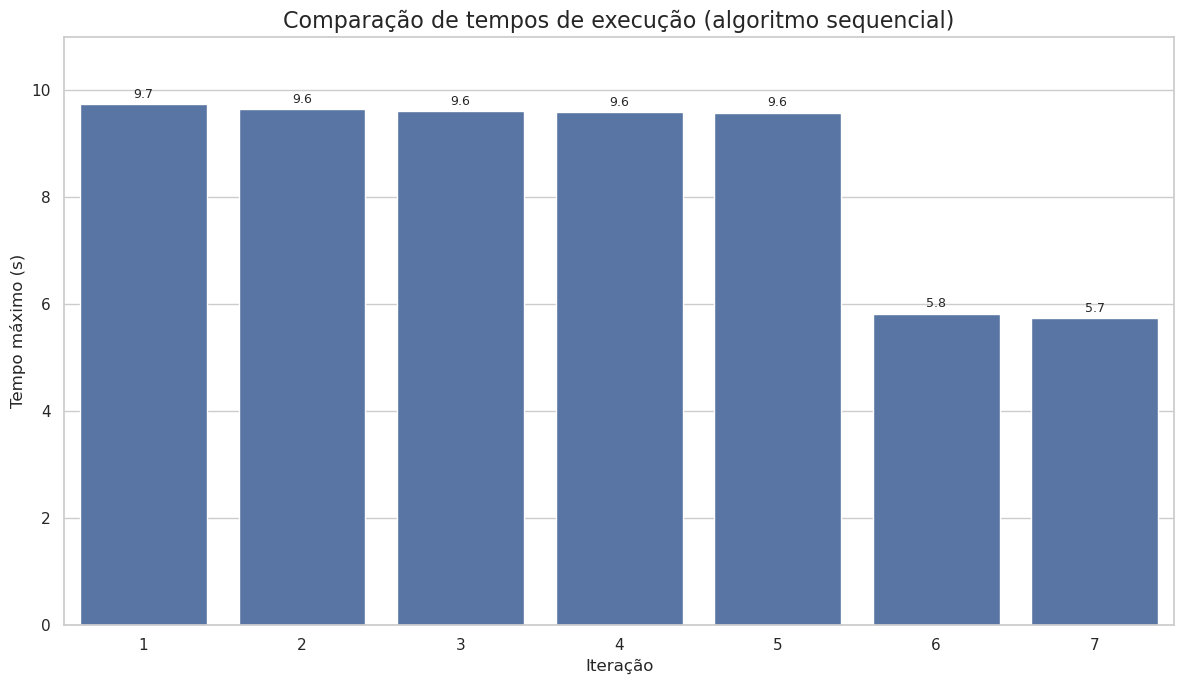

In [15]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=sequencial_df, x="interacao", y="tempo_max")
plt.title("Comparação de tempos de execução (algoritmo sequencial)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)
plt.ylim(0, 11)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

#### MPI

Nesse subcapítulo serão visualizados os dados da implementação paralela com `MPI`.

##### 2 processos

In [16]:
mpi_2_df: pd.DataFrame = results_df.query("nome_modo == 'MPI' and valor_modo == 2")
mpi_2_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
7,1,0.891998,0.892713,0.5,MPI,2,1.000401,0.000801,10.906114,10.914856,5.453057,5.457428
8,2,0.883079,0.883325,0.5,MPI,2,1.000139,0.000278,10.917766,10.920807,5.458883,5.460403
9,3,0.883060,0.883465,0.5,MPI,2,1.000229,0.000458,10.870762,10.875748,5.435381,5.437874
10,4,0.887026,0.887439,0.5,MPI,2,1.000233,0.000466,10.803123,10.808152,5.401561,5.404076
11,5,0.877384,0.877590,0.5,MPI,2,1.000118,0.000236,10.912176,10.914739,5.456088,5.457369
12,6,0.890912,0.891102,0.5,MPI,2,1.000107,0.000214,6.531327,6.532720,3.265664,3.266360
13,7,0.870395,0.870697,0.5,MPI,2,1.000174,0.000347,6.584995,6.587280,3.292498,3.293640


###### Tempo de execução - Maior tempo

In [17]:
print("TEMPO")
print("Média:", mpi_2_df["tempo_max"].mean())
print("Desvio padrão:", mpi_2_df["tempo_max"].std())
print("Valor mínimo:", mpi_2_df["tempo_max"].min())
print("Valor máximo:", mpi_2_df["tempo_max"].max())

TEMPO
Média: 0.8837615
Desvio padrão: 0.007709121
Valor mínimo: 0.870697
Valor máximo: 0.892713


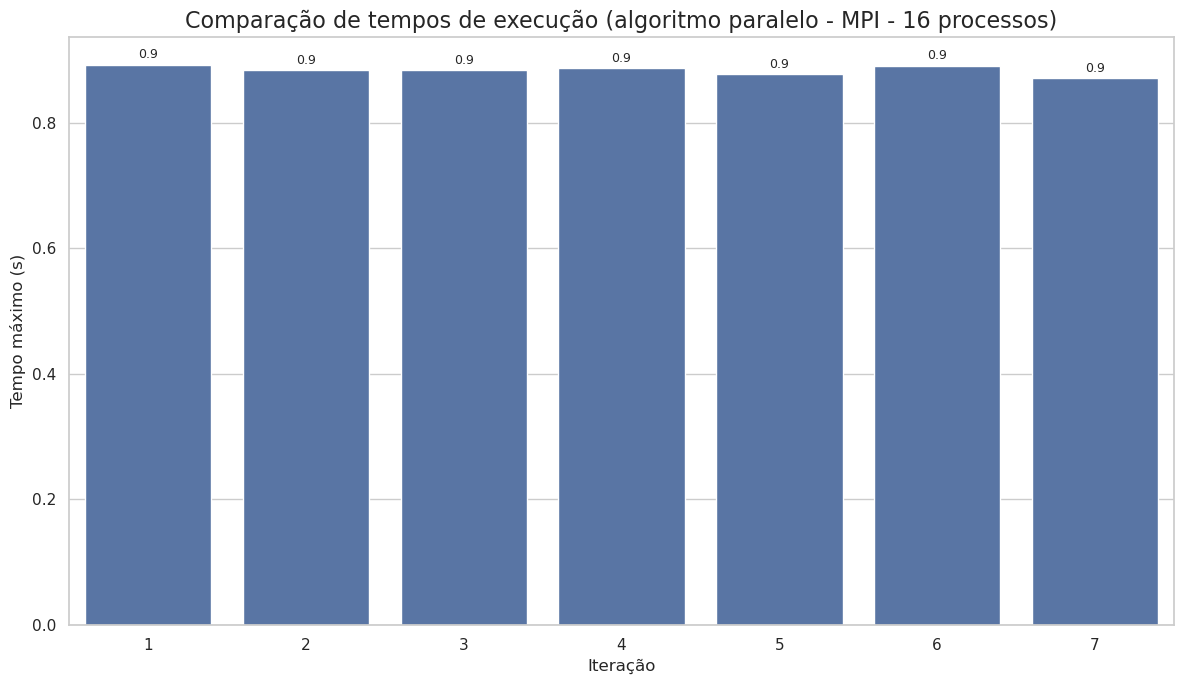

In [18]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="tempo_max")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Tempo de execução - Menor tempo

In [19]:
print("TEMPO")
print("Média:", mpi_2_df["tempo_min"].mean())
print("Desvio padrão:", mpi_2_df["tempo_min"].std())
print("Valor mínimo:", mpi_2_df["tempo_min"].min())
print("Valor máximo:", mpi_2_df["tempo_min"].max())

TEMPO
Média: 0.8834077
Desvio padrão: 0.007627187
Valor mínimo: 0.870395
Valor máximo: 0.891998


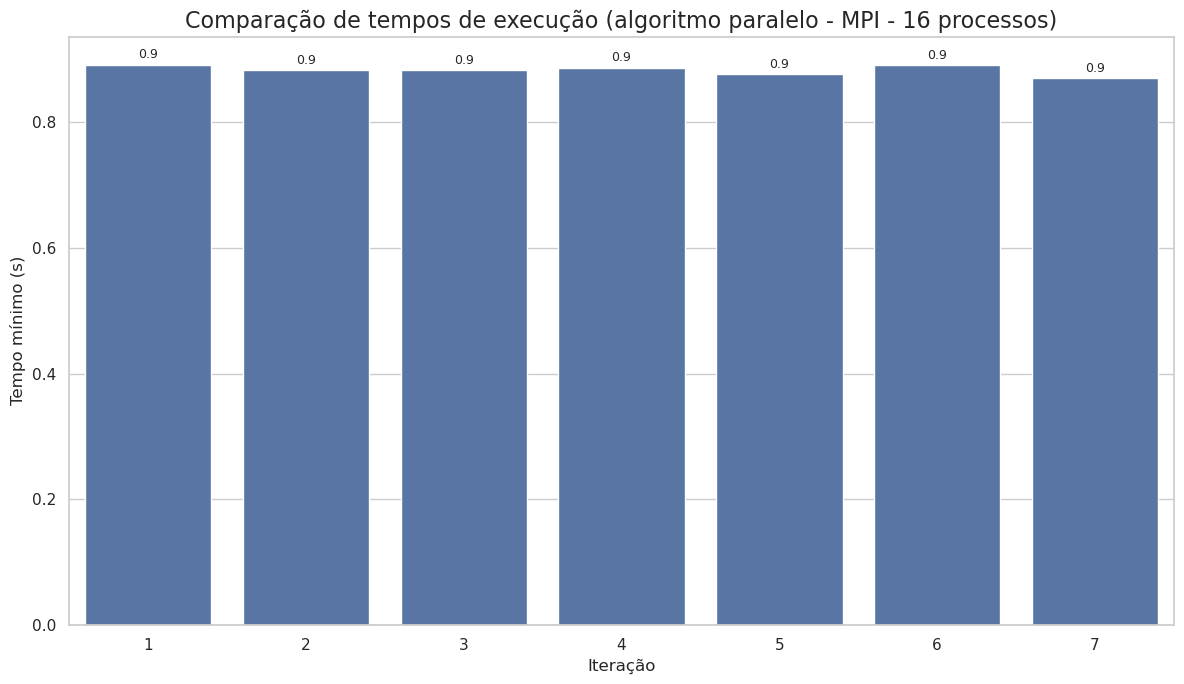

In [20]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="tempo_min")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo mínimo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Fator de balanceamento de carga (Fab) - Tempo Máximo

In [21]:
print("Fab")
print("Média:", mpi_2_df["Fab"].mean())
print("Desvio padrão:", mpi_2_df["Fab"].std())
print("Valor mínimo:", mpi_2_df["Fab"].min())
print("Valor máximo:", mpi_2_df["Fab"].max())

Fab
Média: 1.0002001428571428
Desvio padrão: 0.00010173565184903372
Valor mínimo: 1.000107
Valor máximo: 1.000401


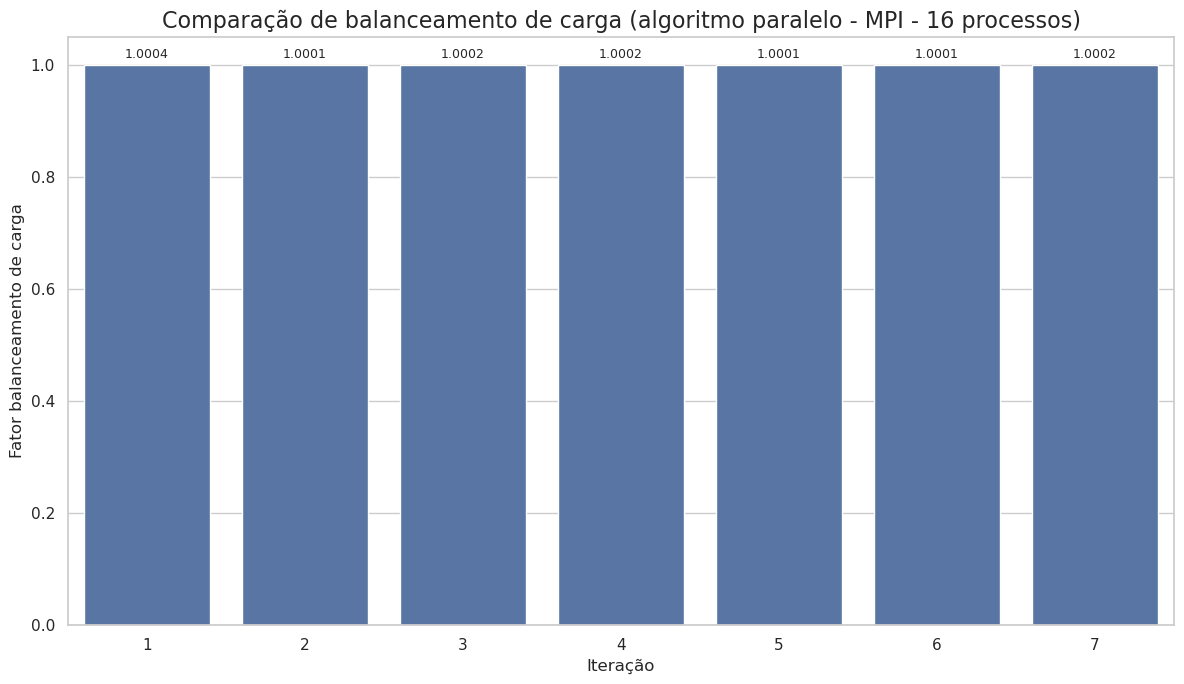

In [22]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Máximo

In [23]:
print("Speed-up")
print("Média:", mpi_2_df["speed_up_max"].mean())
print("Desvio padrão:", mpi_2_df["speed_up_max"].std())
print("Valor mínimo:", mpi_2_df["speed_up_max"].min())
print("Valor máximo:", mpi_2_df["speed_up_max"].max())

Speed-up
Média: 9.646608
Desvio padrão: 2.1102283
Valor mínimo: 6.5313272
Valor máximo: 10.917766


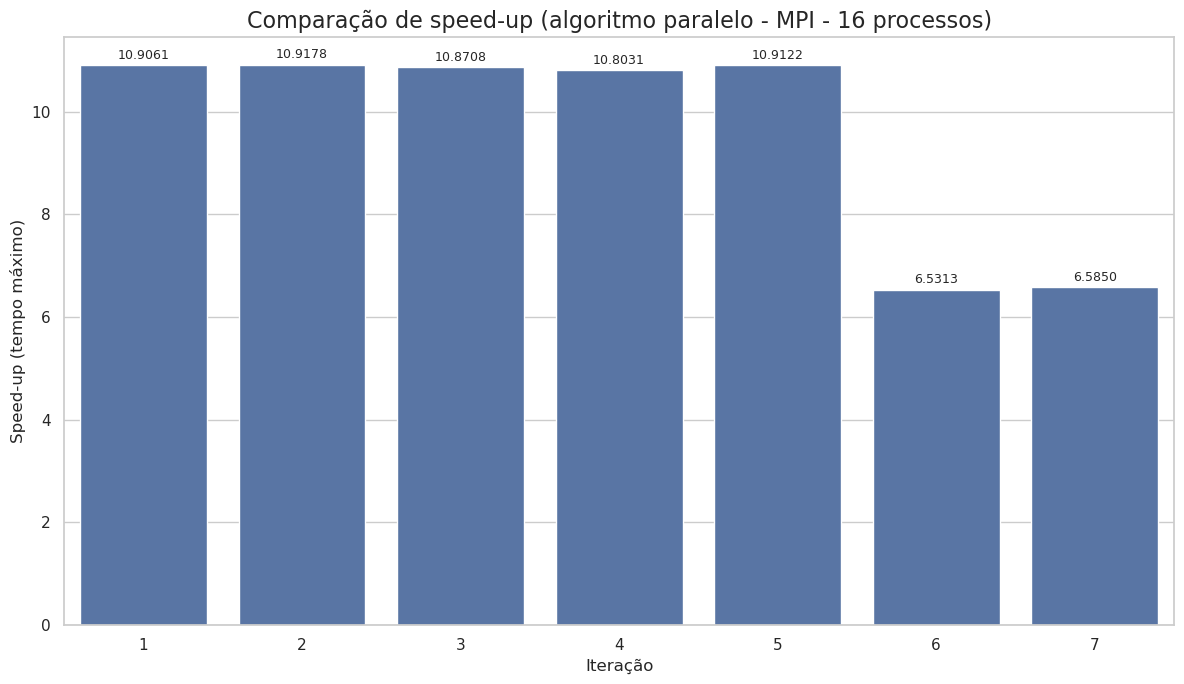

In [24]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="speed_up_max")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo máximo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Mínimo

In [25]:
print("Speed-up")
print("Média:", mpi_2_df["speed_up_min"].mean())
print("Desvio padrão:", mpi_2_df["speed_up_min"].std())
print("Valor mínimo:", mpi_2_df["speed_up_min"].min())
print("Valor máximo:", mpi_2_df["speed_up_min"].max())

Speed-up
Média: 9.650614
Desvio padrão: 2.1117067
Valor mínimo: 6.53272
Valor máximo: 10.920807


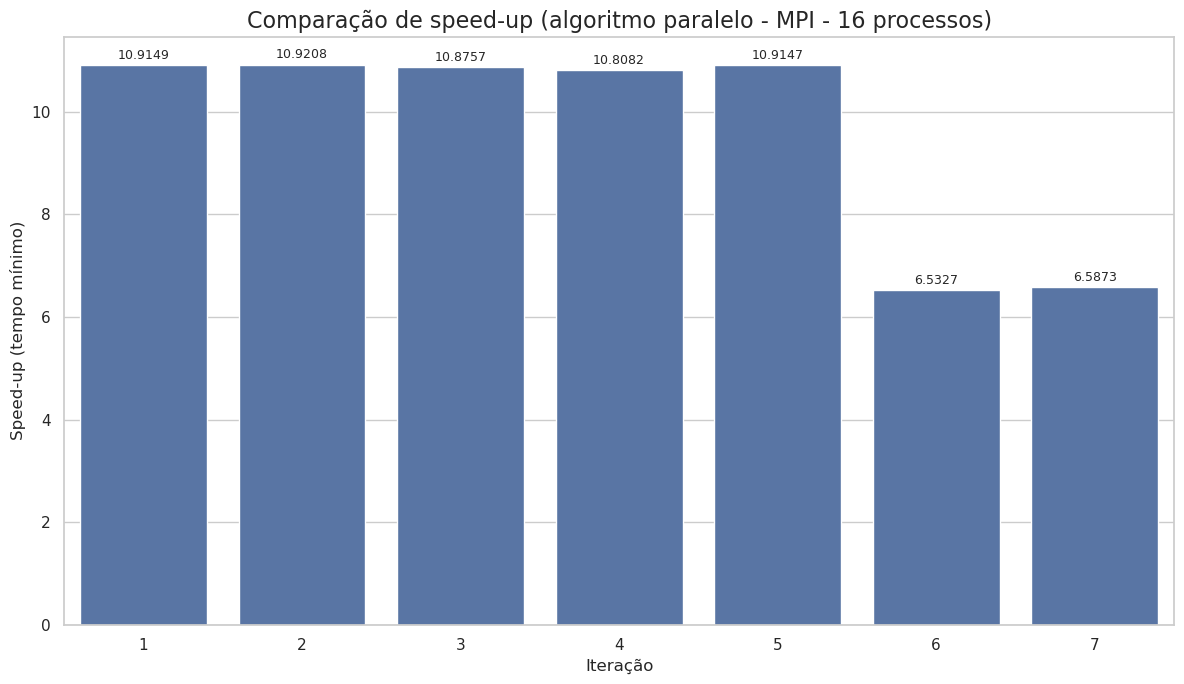

In [26]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="speed_up_min")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo mínimo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Máximo

In [27]:
print("Eficiência")
print("Média:", mpi_2_df["eficiencia_max"].mean())
print("Desvio padrão:", mpi_2_df["eficiencia_max"].std())
print("Valor mínimo:", mpi_2_df["eficiencia_max"].min())
print("Valor máximo:", mpi_2_df["eficiencia_max"].max())

Eficiência
Média: 4.823304448808942
Desvio padrão: 1.0551142121533277
Valor mínimo: 3.2656636238098145
Valor máximo: 5.458882808685303


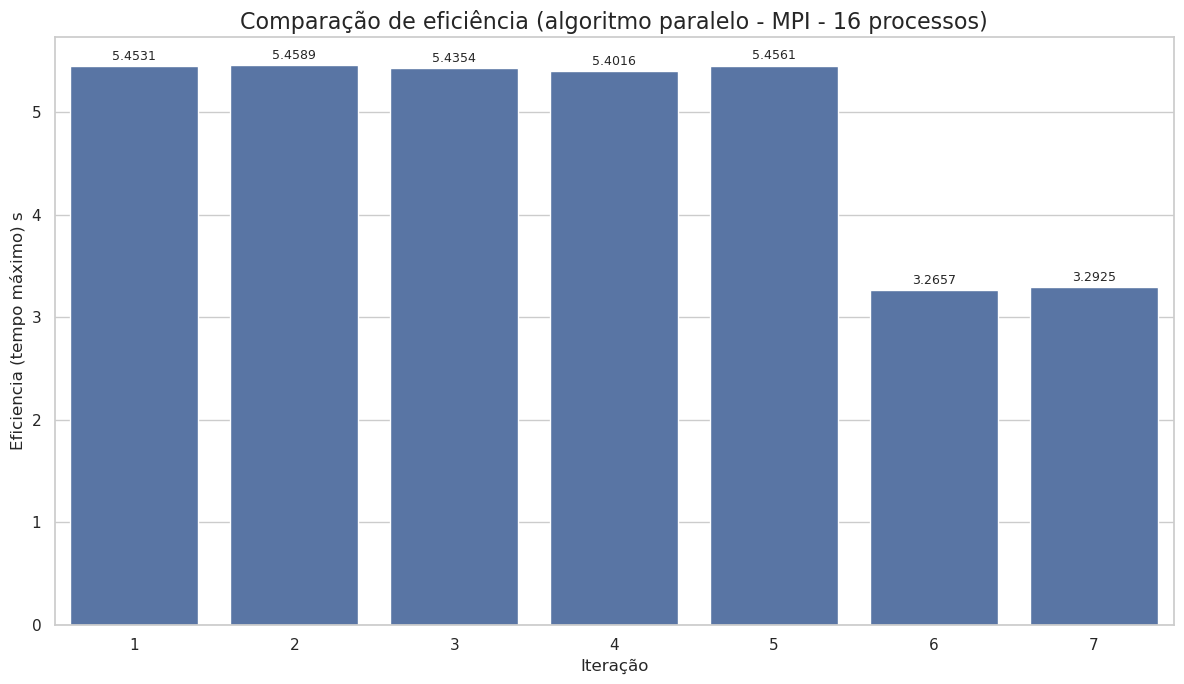

In [28]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="eficiencia_max")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo máximo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Mínimo

In [29]:
print("Eficiência")
print("Média:", mpi_2_df["eficiencia_min"].mean())
print("Desvio padrão:", mpi_2_df["eficiencia_min"].std())
print("Valor mínimo:", mpi_2_df["eficiencia_min"].min())
print("Valor máximo:", mpi_2_df["eficiencia_min"].max())

Eficiência
Média: 4.825307267052787
Desvio padrão: 1.055853367581469
Valor mínimo: 3.26636004447937
Valor máximo: 5.4604034423828125


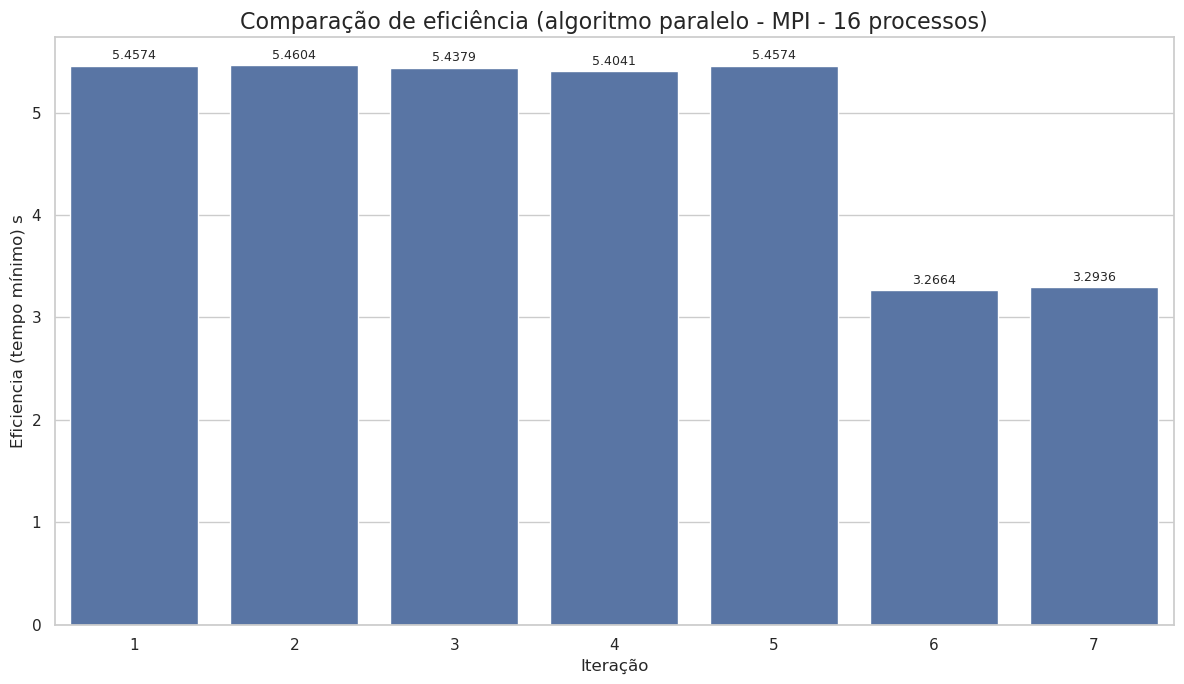

In [30]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_2_df, x="interacao", y="eficiencia_min")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 2 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo mínimo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### 4 processos

In [31]:
mpi_4_df: pd.DataFrame = results_df.query("nome_modo == 'MPI' and valor_modo == 4")
mpi_4_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
14,1,0.557371,0.559152,0.5,MPI,4,1.002308,0.003186,17.412134,17.467772,4.353034,4.366943
15,2,0.557356,0.559885,0.5,MPI,4,1.003205,0.004516,17.224850,17.303007,4.306212,4.325752
16,3,0.558262,0.562634,0.5,MPI,4,1.004683,0.007770,17.069599,17.203279,4.267400,4.300820
17,4,0.550755,0.552215,0.5,MPI,4,1.001792,0.002643,17.361197,17.407217,4.340299,4.351804
18,5,0.558312,0.560350,0.5,MPI,4,1.001590,0.003637,17.090063,17.152447,4.272516,4.288112
19,6,0.548561,0.549641,0.5,MPI,4,1.001265,0.001966,10.588873,10.609721,2.647218,2.652430
20,7,0.542998,0.545196,0.5,MPI,4,1.002740,0.004032,10.516467,10.559036,2.629117,2.639759


###### Tempo de execução - Maior tempo

In [32]:
print("TEMPO")
print("Média:", mpi_4_df["tempo_max"].mean())
print("Desvio padrão:", mpi_4_df["tempo_max"].std())
print("Valor mínimo:", mpi_4_df["tempo_max"].min())
print("Valor máximo:", mpi_4_df["tempo_max"].max())

TEMPO
Média: 0.55558187
Desvio padrão: 0.0065603177
Valor mínimo: 0.545196
Valor máximo: 0.562634


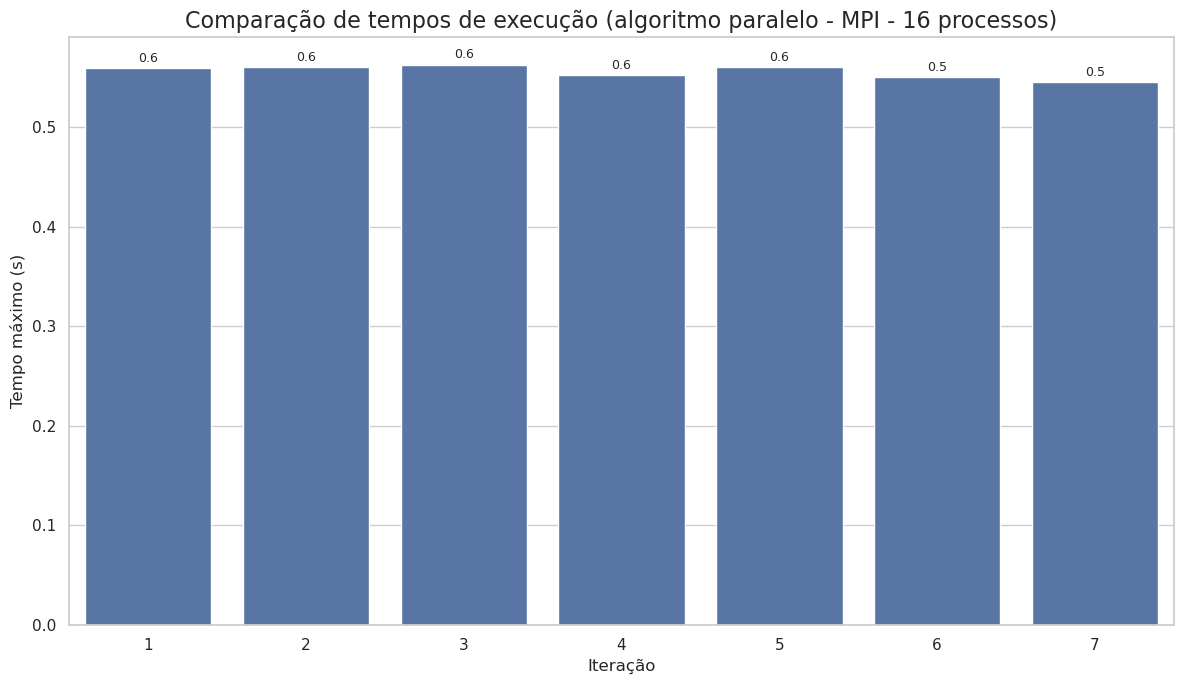

In [33]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="tempo_max")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Tempo de execução - Menor tempo

In [34]:
print("TEMPO")
print("Média:", mpi_4_df["tempo_min"].mean())
print("Desvio padrão:", mpi_4_df["tempo_min"].std())
print("Valor mínimo:", mpi_4_df["tempo_min"].min())
print("Valor máximo:", mpi_4_df["tempo_min"].max())

TEMPO
Média: 0.5533736
Desvio padrão: 0.006024866
Valor mínimo: 0.542998
Valor máximo: 0.558312


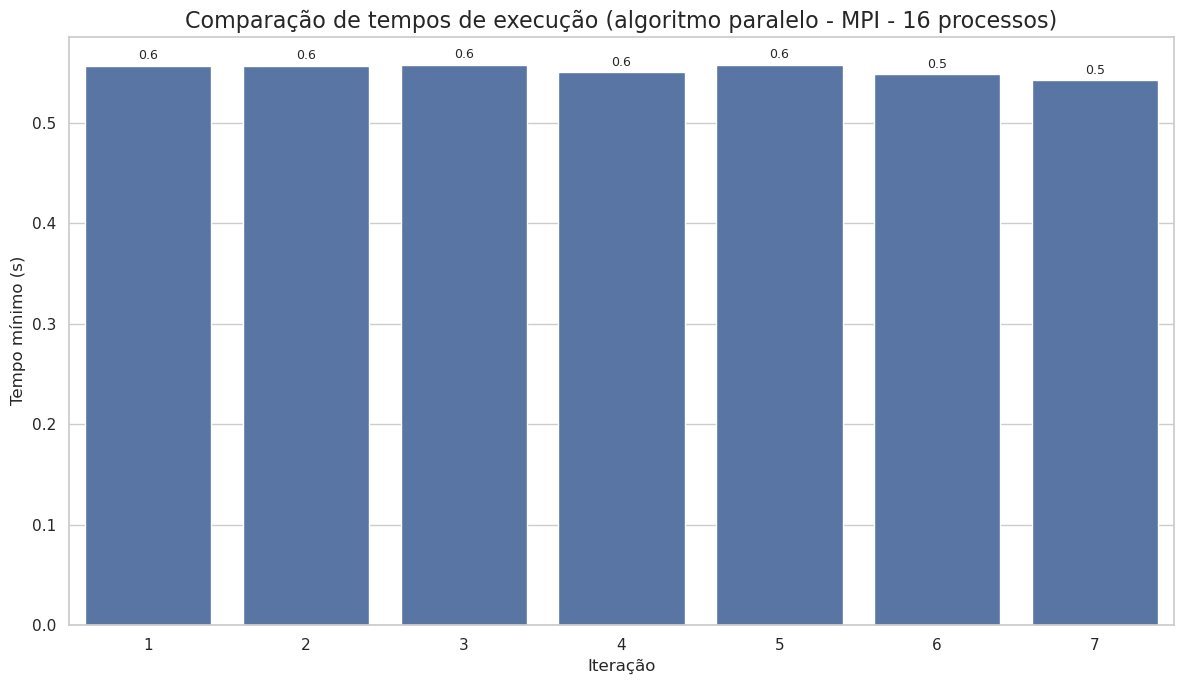

In [35]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="tempo_min")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo mínimo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Fator de balanceamento de carga (Fab) - Tempo Máximo

In [36]:
print("Fab")
print("Média:", mpi_4_df["Fab"].mean())
print("Desvio padrão:", mpi_4_df["Fab"].std())
print("Valor mínimo:", mpi_4_df["Fab"].min())
print("Valor máximo:", mpi_4_df["Fab"].max())

Fab
Média: 1.002511857142857
Desvio padrão: 0.0011697993315908587
Valor mínimo: 1.001265
Valor máximo: 1.004683


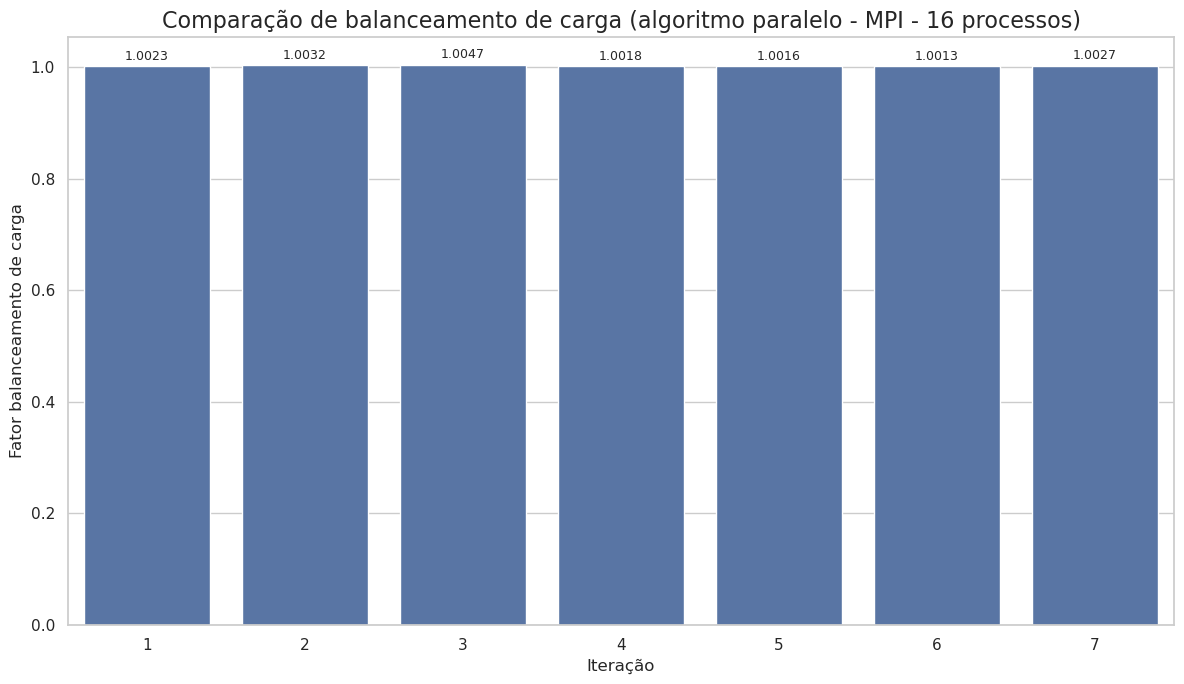

In [37]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Máximo

In [38]:
print("Speed-up")
print("Média:", mpi_4_df["speed_up_max"].mean())
print("Desvio padrão:", mpi_4_df["speed_up_max"].std())
print("Valor mínimo:", mpi_4_df["speed_up_max"].min())
print("Valor máximo:", mpi_4_df["speed_up_max"].max())

Speed-up
Média: 15.323312
Desvio padrão: 3.2614822
Valor mínimo: 10.516467
Valor máximo: 17.412134


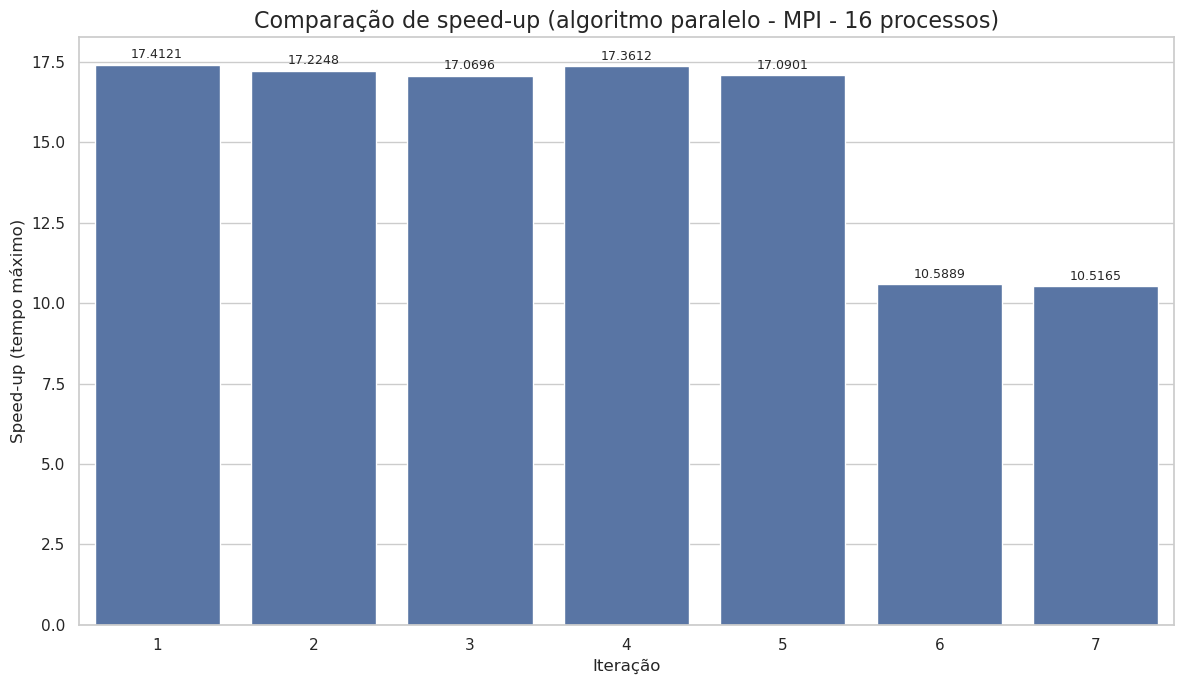

In [39]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="speed_up_max")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo máximo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Mínimo

In [40]:
print("Speed-up")
print("Média:", mpi_4_df["speed_up_min"].mean())
print("Desvio padrão:", mpi_4_df["speed_up_min"].std())
print("Valor mínimo:", mpi_4_df["speed_up_min"].min())
print("Valor máximo:", mpi_4_df["speed_up_min"].max())

Speed-up
Média: 15.386068
Desvio padrão: 3.2820032
Valor mínimo: 10.559036
Valor máximo: 17.467772


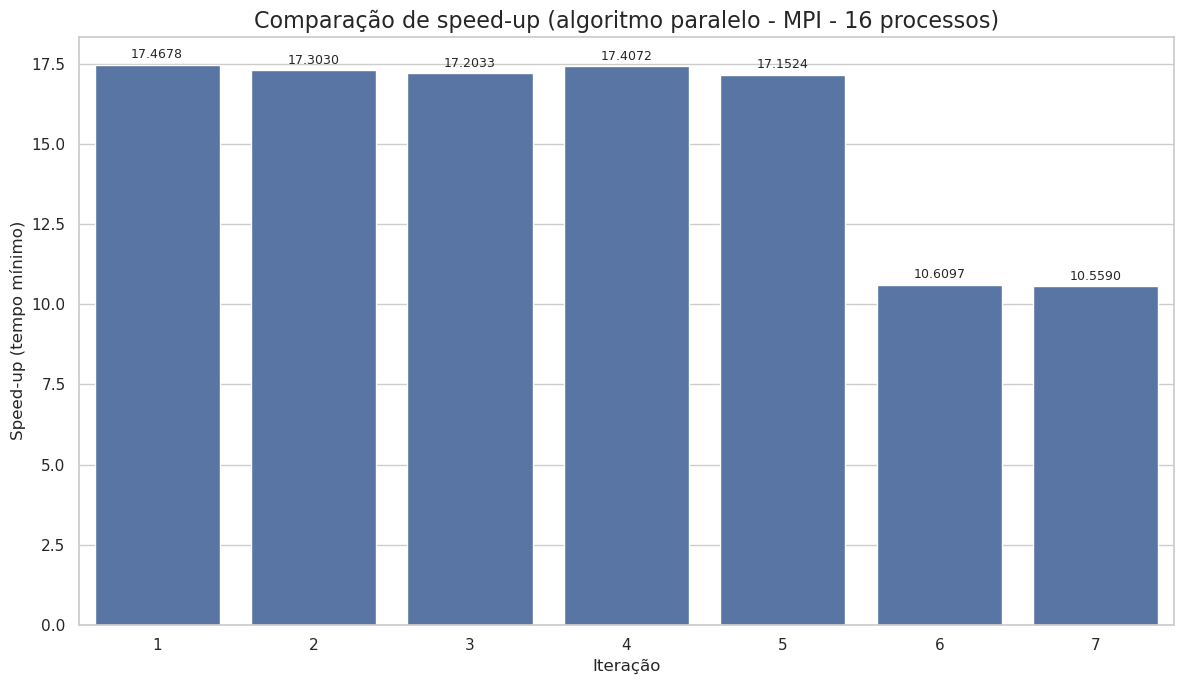

In [41]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="speed_up_min")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo mínimo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Máximo

In [42]:
print("Eficiência")
print("Média:", mpi_4_df["eficiencia_max"].mean())
print("Desvio padrão:", mpi_4_df["eficiencia_max"].std())
print("Valor mínimo:", mpi_4_df["eficiencia_max"].min())
print("Valor máximo:", mpi_4_df["eficiencia_max"].max())

Eficiência
Média: 3.8308279514312744
Desvio padrão: 0.8153705490197047
Valor mínimo: 2.6291167736053467
Valor máximo: 4.353033542633057


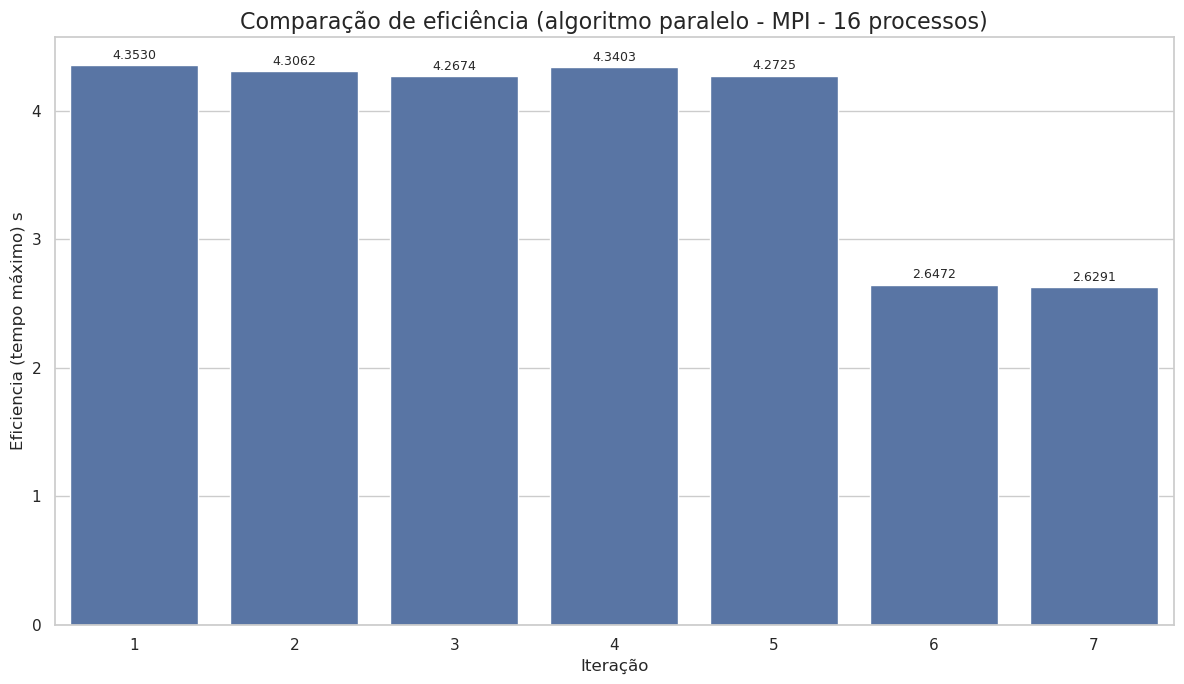

In [43]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="eficiencia_max")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo máximo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Mínimo

In [44]:
print("Eficiência")
print("Média:", mpi_4_df["eficiencia_min"].mean())
print("Desvio padrão:", mpi_4_df["eficiencia_min"].std())
print("Valor mínimo:", mpi_4_df["eficiencia_min"].min())
print("Valor máximo:", mpi_4_df["eficiencia_min"].max())

Eficiência
Média: 3.84651712008885
Desvio padrão: 0.8205007646304302
Valor mínimo: 2.639759063720703
Valor máximo: 4.366942882537842


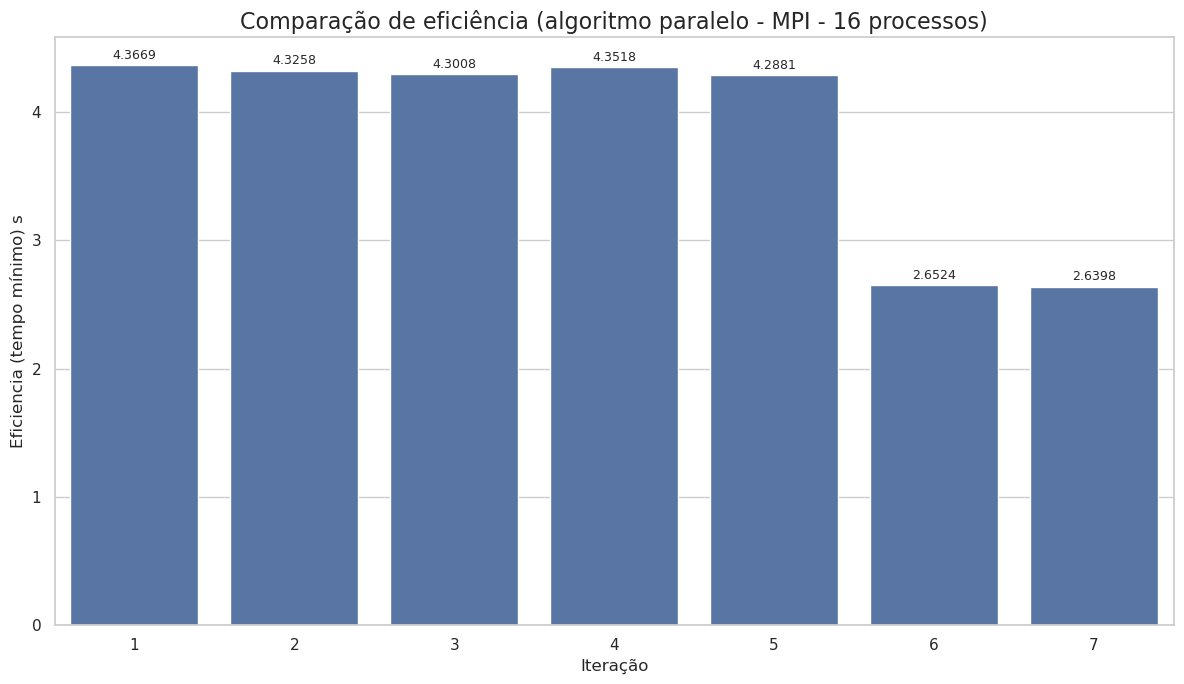

In [45]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_4_df, x="interacao", y="eficiencia_min")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 4 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo mínimo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### 8 processos

In [46]:
mpi_8_df: pd.DataFrame = results_df.query("nome_modo == 'MPI' and valor_modo == 8")
mpi_8_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
21,1,0.396705,0.404967,0.5,MPI,8,1.011895,0.020403,24.041538,24.542240,3.005192,3.067780
22,2,0.403955,0.408958,0.5,MPI,8,1.007551,0.012233,23.581726,23.873785,2.947716,2.984223
23,3,0.401455,0.402796,0.5,MPI,8,1.001910,0.003331,23.843180,23.922825,2.980397,2.990353
24,4,0.403048,0.408533,0.5,MPI,8,1.007728,0.013425,23.467167,23.786528,2.933396,2.973316
25,5,0.403822,0.406054,0.5,MPI,8,1.003089,0.005498,23.584097,23.714451,2.948012,2.964306
26,6,0.404525,0.408664,0.5,MPI,8,1.005832,0.010130,14.241722,14.387439,1.780215,1.798430
27,7,0.404549,0.408846,0.5,MPI,8,1.006068,0.010511,14.023705,14.172661,1.752963,1.771583


###### Tempo de execução - Maior tempo

In [47]:
print("TEMPO")
print("Média:", mpi_8_df["tempo_max"].mean())
print("Desvio padrão:", mpi_8_df["tempo_max"].std())
print("Valor mínimo:", mpi_8_df["tempo_max"].min())
print("Valor máximo:", mpi_8_df["tempo_max"].max())

TEMPO
Média: 0.406974
Desvio padrão: 0.0024172033
Valor mínimo: 0.402796
Valor máximo: 0.408958


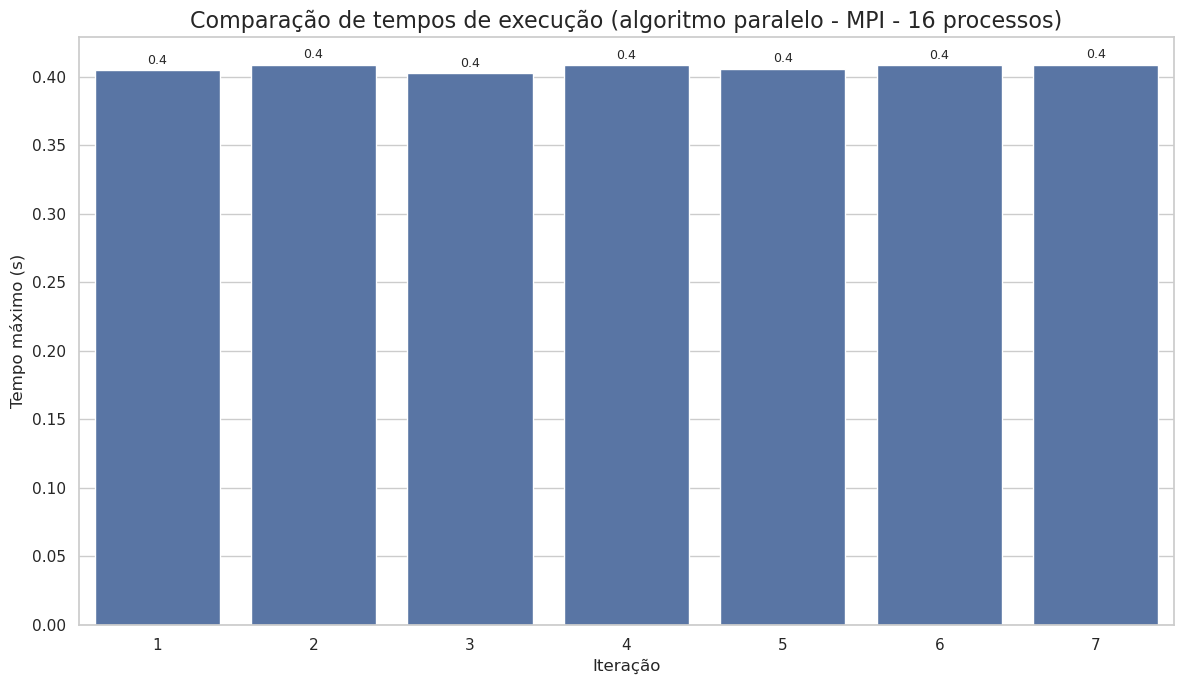

In [48]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="tempo_max")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 8 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Tempo de execução - Menor tempo

In [49]:
print("TEMPO")
print("Média:", mpi_8_df["tempo_min"].mean())
print("Desvio padrão:", mpi_8_df["tempo_min"].std())
print("Valor mínimo:", mpi_8_df["tempo_min"].min())
print("Valor máximo:", mpi_8_df["tempo_min"].max())

TEMPO
Média: 0.40257984
Desvio padrão: 0.002801594
Valor mínimo: 0.396705
Valor máximo: 0.404549


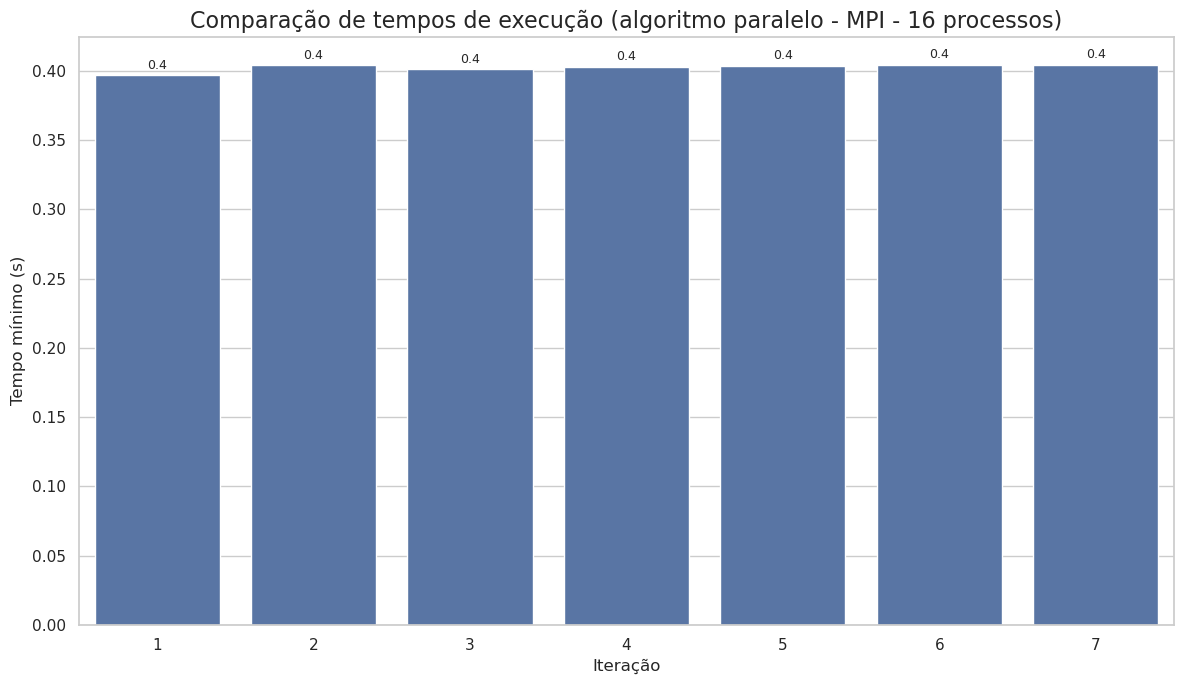

In [50]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="tempo_min")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 8 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo mínimo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Fator de balanceamento de carga (Fab) - Tempo Máximo

In [51]:
print("Fab")
print("Média:", mpi_8_df["Fab"].mean())
print("Desvio padrão:", mpi_8_df["Fab"].std())
print("Valor mínimo:", mpi_8_df["Fab"].min())
print("Valor máximo:", mpi_8_df["Fab"].max())

Fab
Média: 1.0062961428571429
Desvio padrão: 0.0032854115636944373
Valor mínimo: 1.00191
Valor máximo: 1.011895


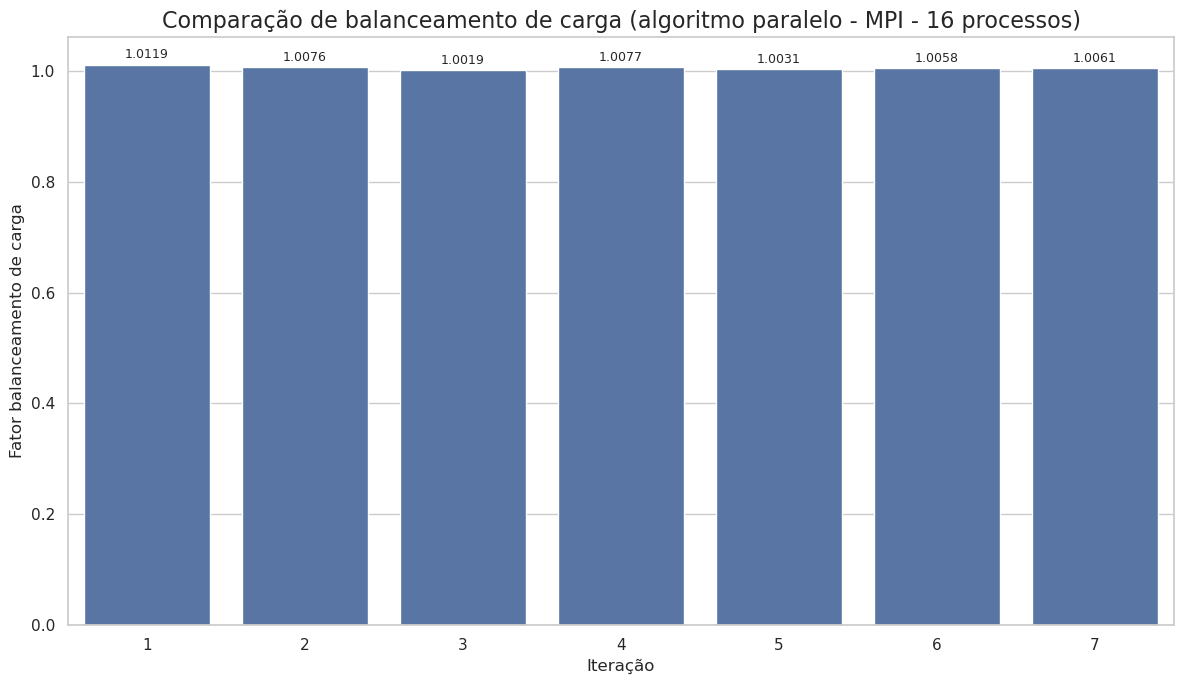

In [52]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - MPI - 8 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Máximo

In [53]:
print("Speed-up")
print("Média:", mpi_8_df["speed_up_max"].mean())
print("Desvio padrão:", mpi_8_df["speed_up_max"].std())
print("Valor mínimo:", mpi_8_df["speed_up_max"].min())
print("Valor máximo:", mpi_8_df["speed_up_max"].max())

Speed-up
Média: 20.96902
Desvio padrão: 4.674411
Valor mínimo: 14.0237055
Valor máximo: 24.041538


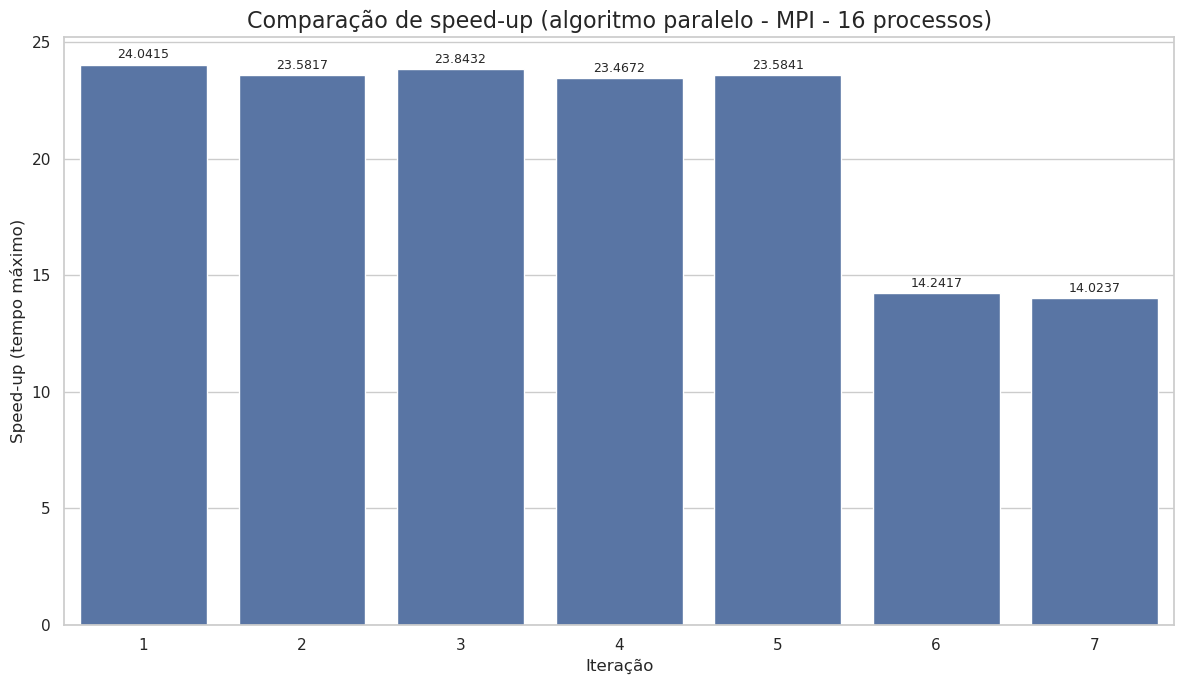

In [54]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="speed_up_max")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo máximo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Mínimo

In [55]:
print("Speed-up")
print("Média:", mpi_8_df["speed_up_min"].mean())
print("Desvio padrão:", mpi_8_df["speed_up_min"].std())
print("Valor mínimo:", mpi_8_df["speed_up_min"].min())
print("Valor máximo:", mpi_8_df["speed_up_min"].max())

Speed-up
Média: 21.199991
Desvio padrão: 4.7353377
Valor mínimo: 14.172661
Valor máximo: 24.54224


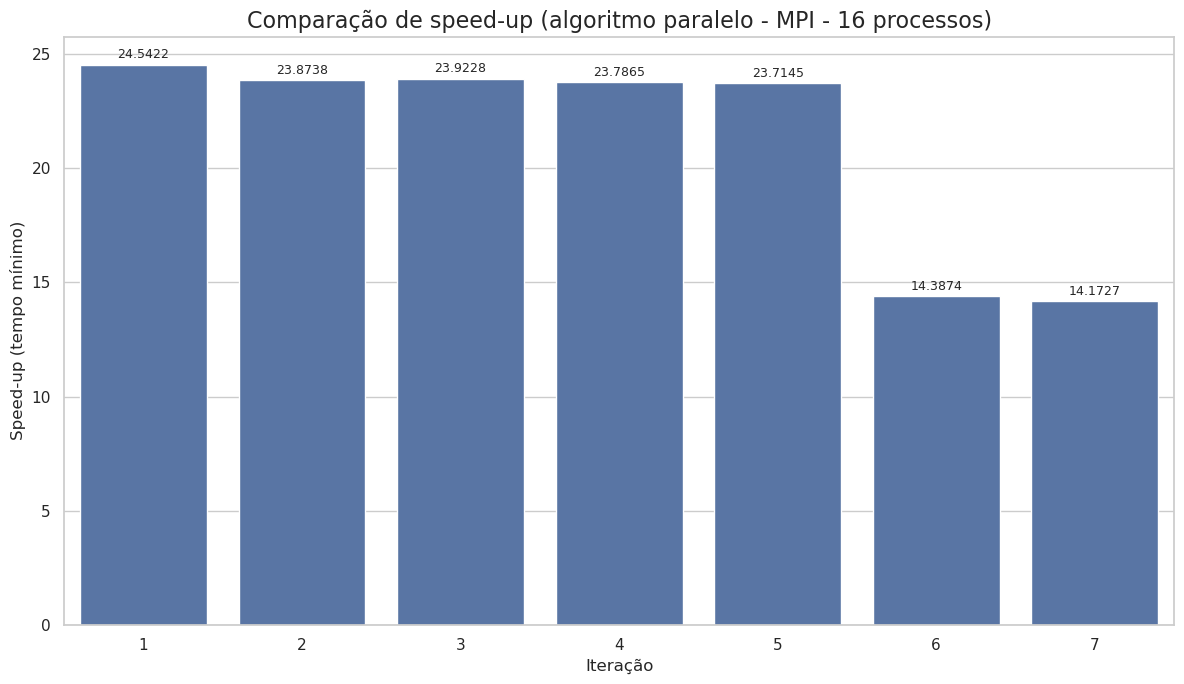

In [56]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="speed_up_min")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 8 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo mínimo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Máximo

In [57]:
print("Eficiência")
print("Média:", mpi_8_df["eficiencia_max"].mean())
print("Desvio padrão:", mpi_8_df["eficiencia_max"].std())
print("Valor mínimo:", mpi_8_df["eficiencia_max"].min())
print("Valor máximo:", mpi_8_df["eficiencia_max"].max())

Eficiência
Média: 2.621127418109349
Desvio padrão: 0.5843013349680771
Valor mínimo: 1.7529631853103638
Valor máximo: 3.005192279815674


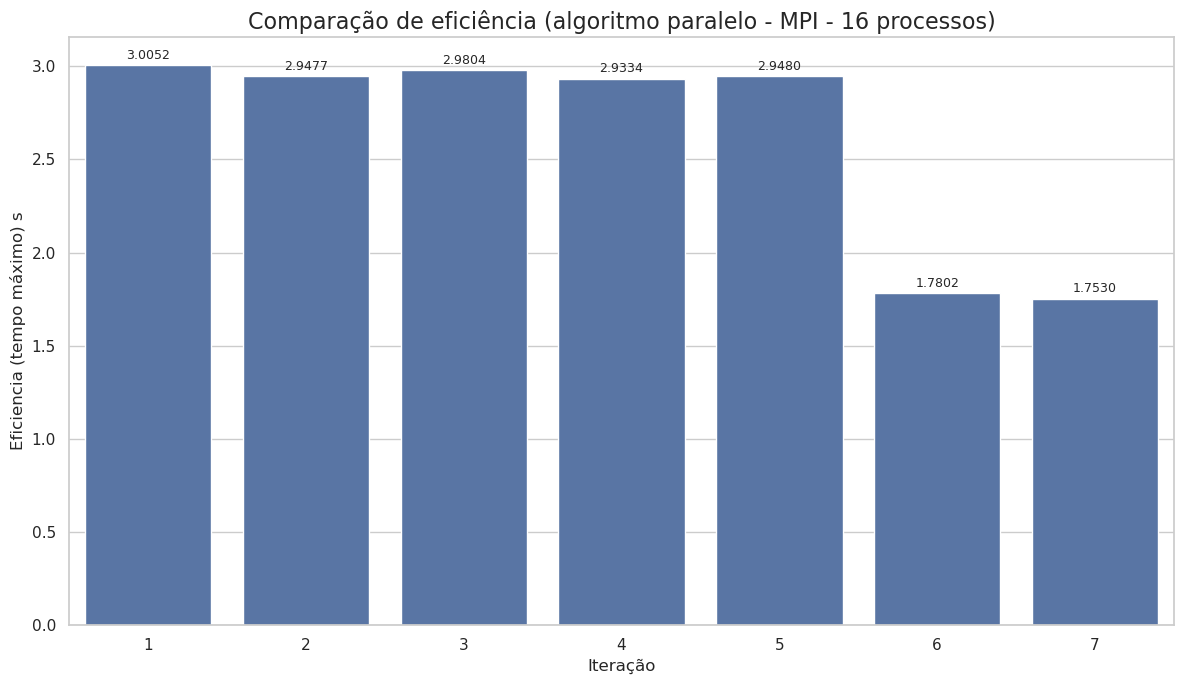

In [58]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="eficiencia_max")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo máximo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Mínimo

In [59]:
print("Eficiência")
print("Média:", mpi_8_df["eficiencia_min"].mean())
print("Desvio padrão:", mpi_8_df["eficiencia_min"].std())
print("Valor mínimo:", mpi_8_df["eficiencia_min"].min())
print("Valor máximo:", mpi_8_df["eficiencia_min"].max())

Eficiência
Média: 2.6499987159456526
Desvio padrão: 0.591917226631595
Valor mínimo: 1.7715826034545898
Valor máximo: 3.067780017852783


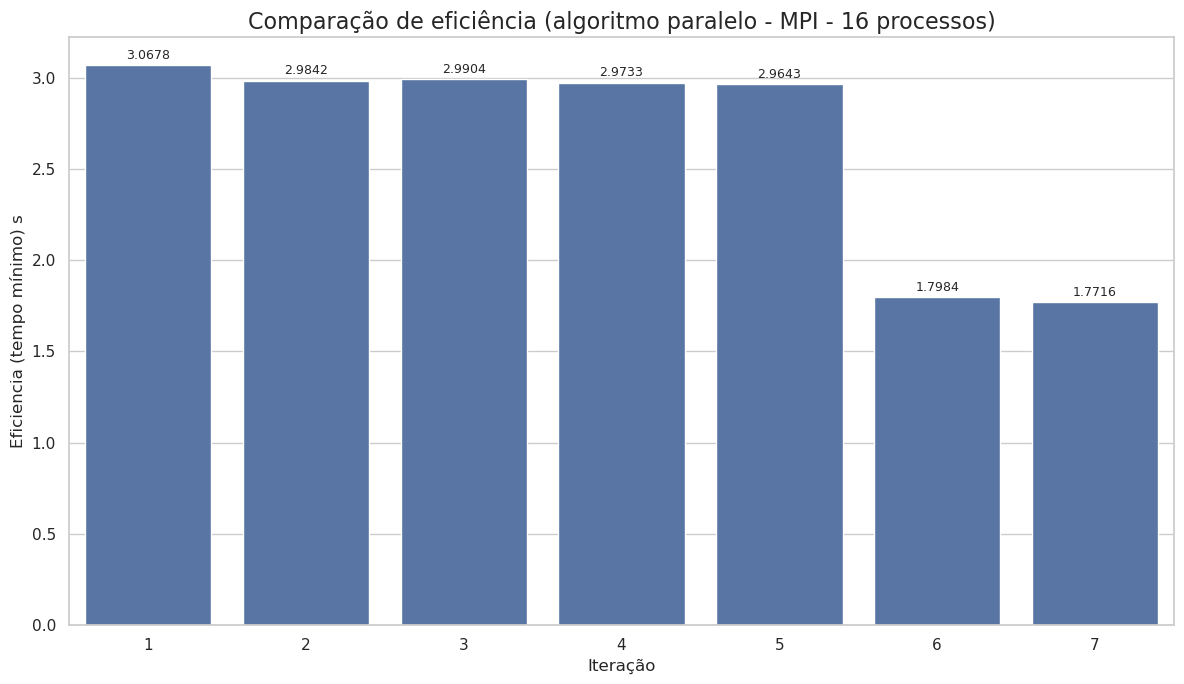

In [60]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_8_df, x="interacao", y="eficiencia_min")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 8 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo mínimo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

##### 16 processos

In [61]:
mpi_16_df: pd.DataFrame = results_df.query("nome_modo == 'MPI' and valor_modo == 16")
mpi_16_df.head(10)

,interacao,tempo_min,tempo_max,threshold,nome_modo,valor_modo,Fab,disparidade_min_max,speed_up_max,speed_up_min,eficiencia_max,eficiencia_min
28,1,0.353700,0.497154,0.5,MPI,16,1.131472,0.288550,19.583529,27.526236,1.223971,1.720390
29,2,0.354957,0.498582,0.5,MPI,16,1.131502,0.288066,19.342726,27.169304,1.208920,1.698081
30,3,0.361922,0.498701,0.5,MPI,16,1.122828,0.274271,19.257906,26.535931,1.203619,1.658496
31,4,0.354048,0.500365,0.5,MPI,16,1.133114,0.292421,19.160236,27.078566,1.197515,1.692410
32,5,0.353348,0.494509,0.5,MPI,16,1.128868,0.285456,19.365505,27.101942,1.210344,1.693871
33,6,0.352501,0.493787,0.5,MPI,16,1.129247,0.286127,11.786618,16.510815,0.736664,1.031926
34,7,0.352616,0.494861,0.5,MPI,16,1.130411,0.287444,11.586154,16.259998,0.724135,1.016250


###### Tempo de execução - Maior tempo

In [62]:
print("TEMPO")
print("Média:", mpi_16_df["tempo_max"].mean())
print("Desvio padrão:", mpi_16_df["tempo_max"].std())
print("Valor mínimo:", mpi_16_df["tempo_max"].min())
print("Valor máximo:", mpi_16_df["tempo_max"].max())

TEMPO
Média: 0.4968513
Desvio padrão: 0.0025063977
Valor mínimo: 0.493787
Valor máximo: 0.500365


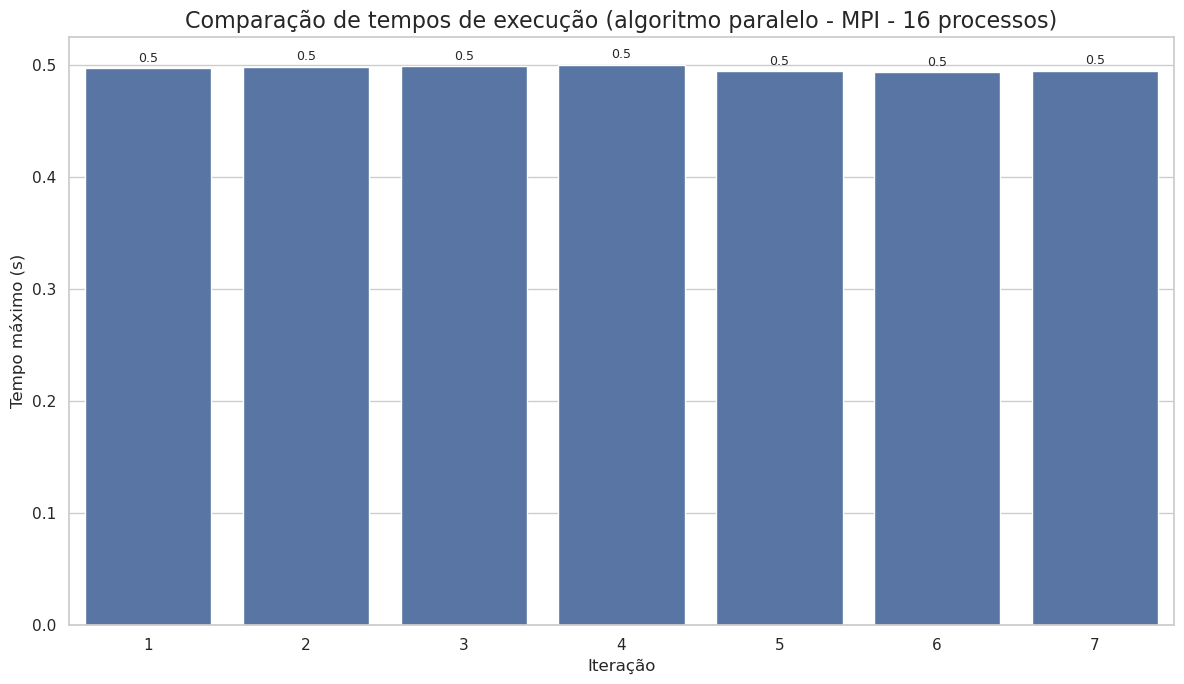

In [63]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="tempo_max")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Tempo de execução - Menor tempo

In [64]:
print("TEMPO")
print("Média:", mpi_16_df["tempo_min"].mean())
print("Desvio padrão:", mpi_16_df["tempo_min"].std())
print("Valor mínimo:", mpi_16_df["tempo_min"].min())
print("Valor máximo:", mpi_16_df["tempo_min"].max())

TEMPO
Média: 0.35472745
Desvio padrão: 0.0032825193
Valor mínimo: 0.352501
Valor máximo: 0.361922


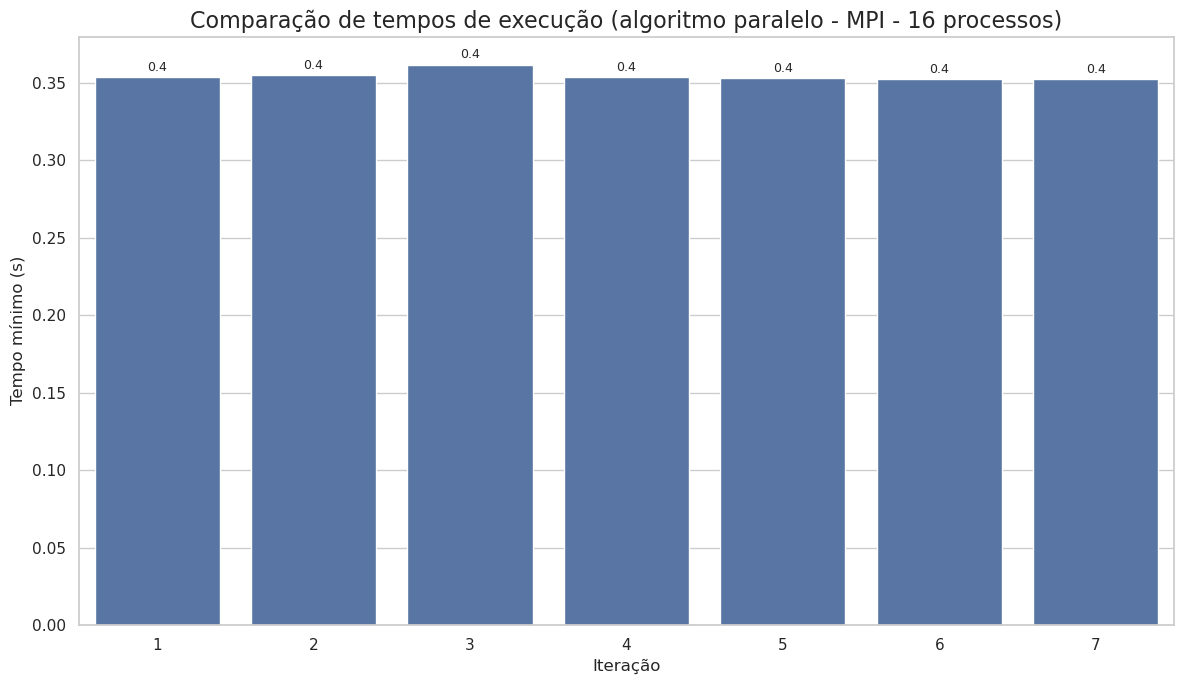

In [65]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="tempo_min")
plt.title("Comparação de tempos de execução (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo mínimo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7),
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Fator de balanceamento de carga (Fab) - Tempo Máximo

In [66]:
print("Fab")
print("Média:", mpi_16_df["Fab"].mean())
print("Desvio padrão:", mpi_16_df["Fab"].std())
print("Valor mínimo:", mpi_16_df["Fab"].min())
print("Valor máximo:", mpi_16_df["Fab"].max())

Fab
Média: 1.1296345714285714
Desvio padrão: 0.003332665492622149
Valor mínimo: 1.122828
Valor máximo: 1.133114


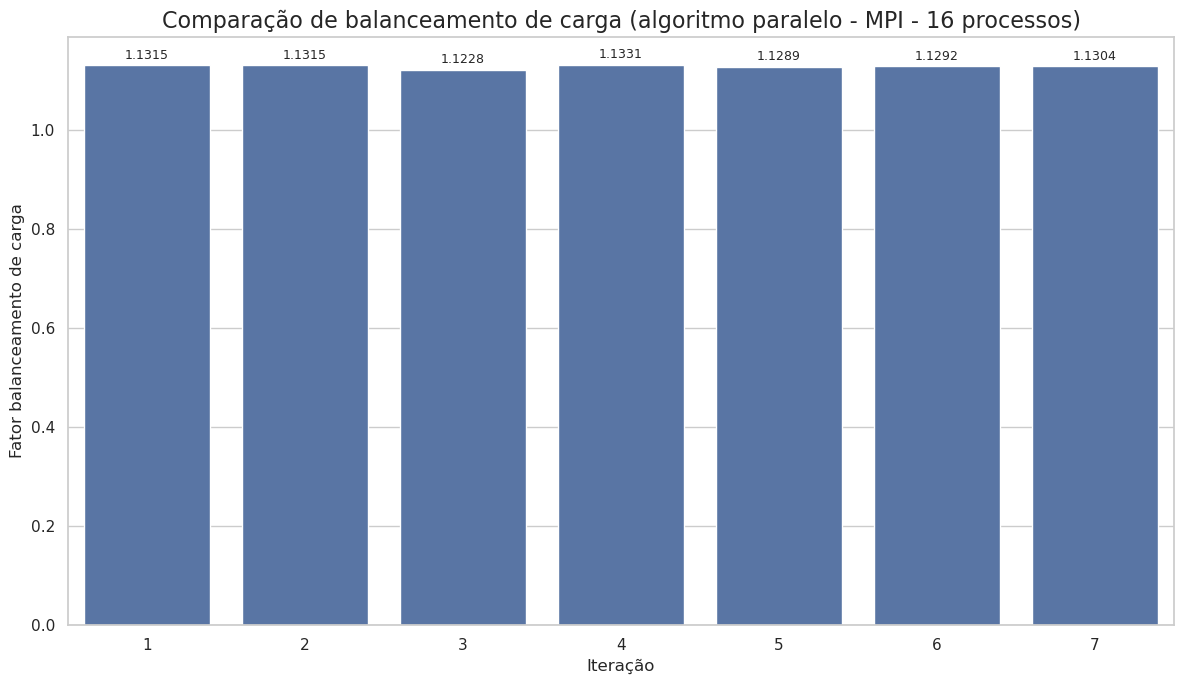

In [67]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="Fab")
plt.title("Comparação de balanceamento de carga (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator balanceamento de carga", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Máximo

In [68]:
print("Speed-up")
print("Média:", mpi_16_df["speed_up_max"].mean())
print("Desvio padrão:", mpi_16_df["speed_up_max"].std())
print("Valor mínimo:", mpi_16_df["speed_up_max"].min())
print("Valor máximo:", mpi_16_df["speed_up_max"].max())

Speed-up
Média: 17.154667
Desvio padrão: 3.7382033
Valor mínimo: 11.586154
Valor máximo: 19.583529


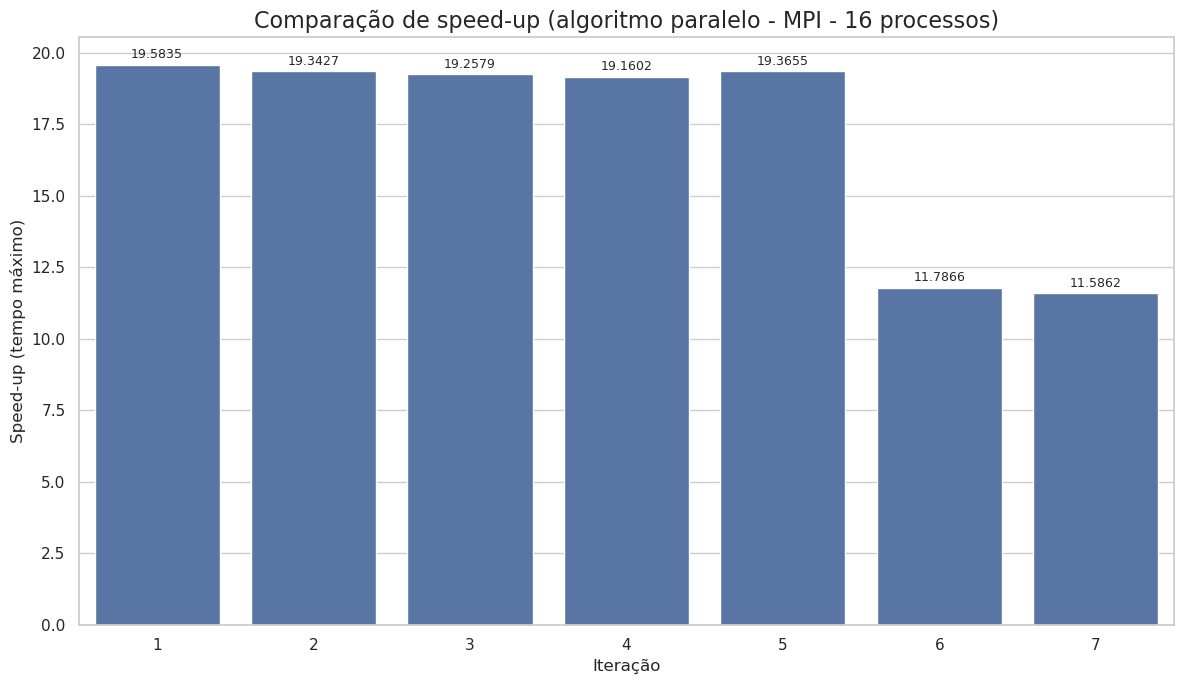

In [69]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="speed_up_max")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo máximo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### *Speed-up* - Tempo Mínimo

In [70]:
print("Speed-up")
print("Média:", mpi_16_df["speed_up_min"].mean())
print("Desvio padrão:", mpi_16_df["speed_up_min"].std())
print("Valor mínimo:", mpi_16_df["speed_up_min"].min())
print("Valor máximo:", mpi_16_df["speed_up_min"].max())

Speed-up
Média: 24.026114
Desvio padrão: 5.2281313
Valor mínimo: 16.259998
Valor máximo: 27.526236


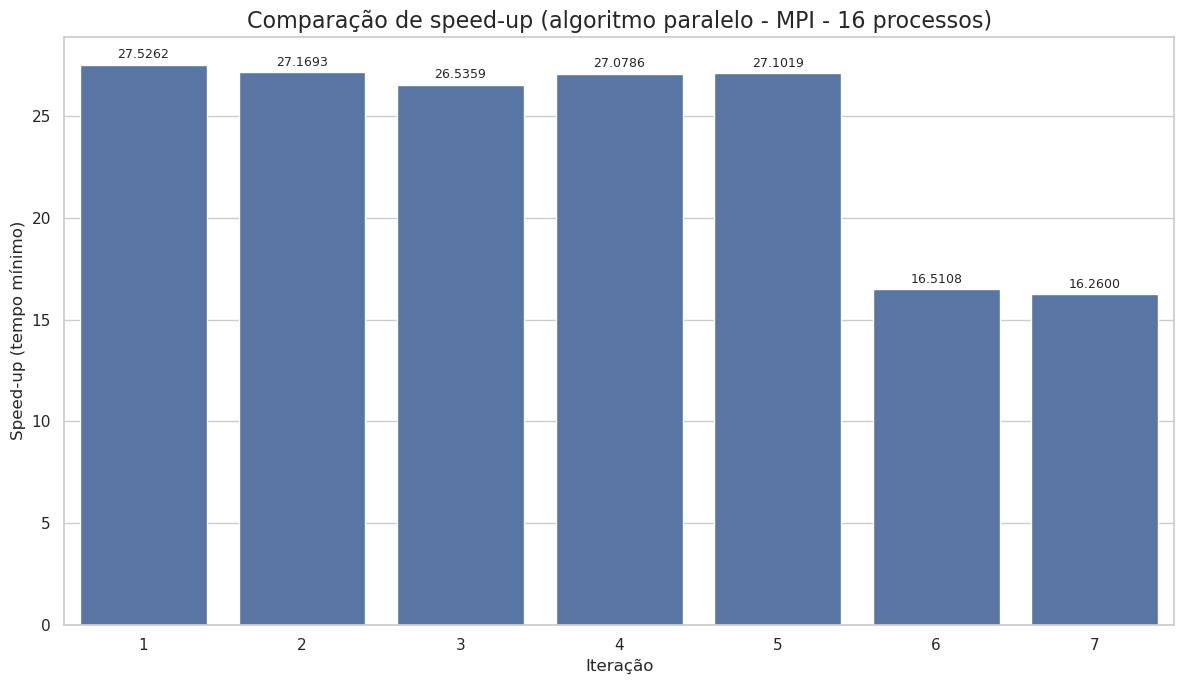

In [71]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="speed_up_min")
plt.title("Comparação de speed-up (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Speed-up (tempo mínimo)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Máximo

In [72]:
print("Eficiência")
print("Média:", mpi_16_df["eficiencia_max"].mean())
print("Desvio padrão:", mpi_16_df["eficiencia_max"].std())
print("Valor mínimo:", mpi_16_df["eficiencia_max"].min())
print("Valor máximo:", mpi_16_df["eficiencia_max"].max())

Eficiência
Média: 1.0721667323793684
Desvio padrão: 0.23363770470970874
Valor mínimo: 0.724134624004364
Valor máximo: 1.2239705324172974


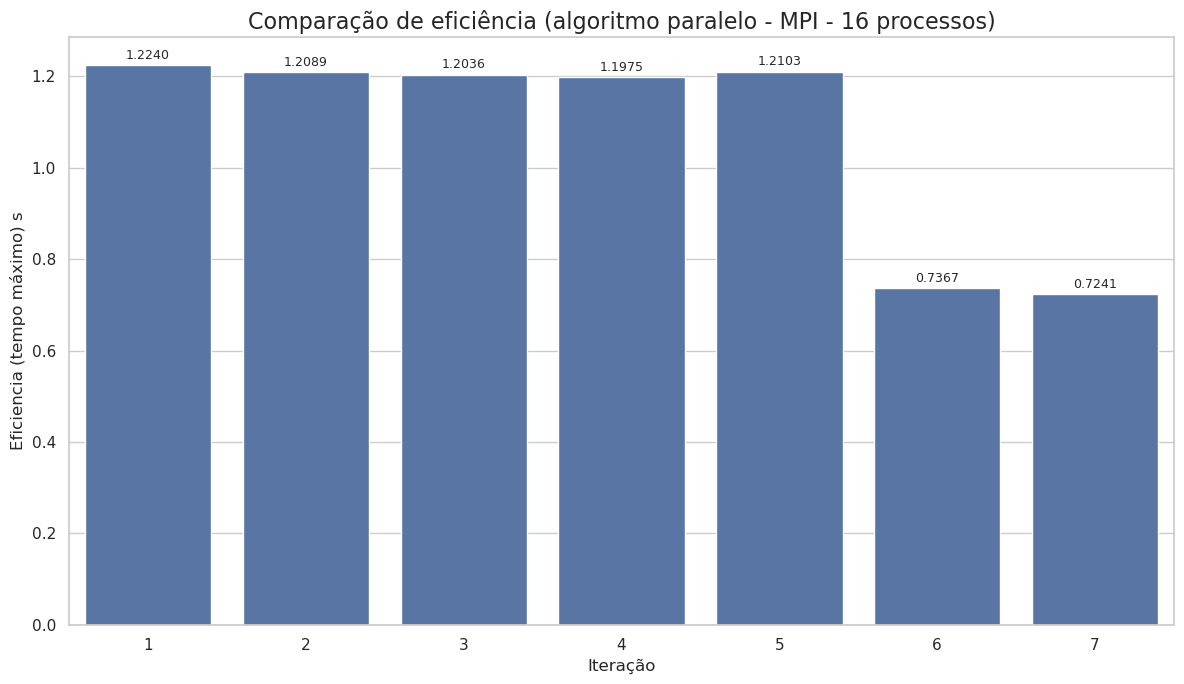

In [73]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="eficiencia_max")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo máximo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

###### Eficiência - Tempo Mínimo

In [74]:
print("Eficiência")
print("Média:", mpi_16_df["eficiencia_min"].mean())
print("Desvio padrão:", mpi_16_df["eficiencia_min"].std())
print("Valor mínimo:", mpi_16_df["eficiencia_min"].min())
print("Valor máximo:", mpi_16_df["eficiencia_min"].max())

Eficiência
Média: 1.5016320603234428
Desvio padrão: 0.326758194102161
Valor mínimo: 1.0162498950958252
Valor máximo: 1.720389723777771


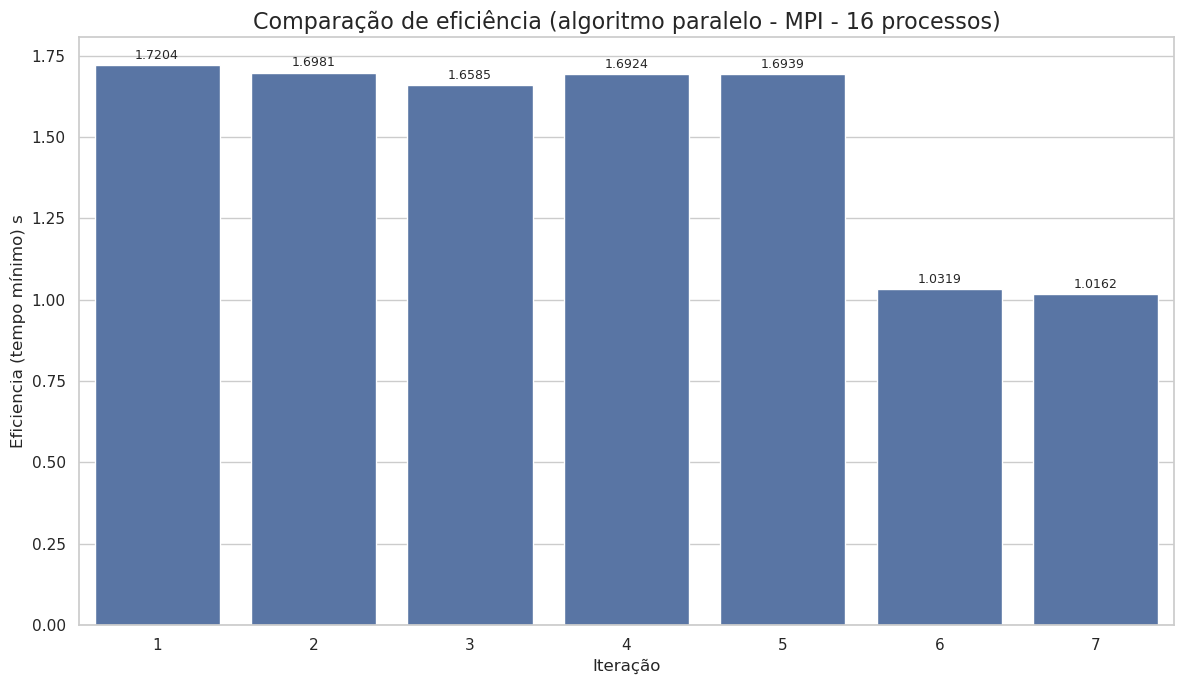

In [75]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=mpi_16_df, x="interacao", y="eficiencia_min")
plt.title("Comparação de eficiência (algoritmo paralelo - MPI - 16 processos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo mínimo) s", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".4f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
del mpi_2_df
del mpi_4_df
del mpi_8_df
del mpi_16_df

#### MPI - Todos juntos

In [77]:
mpi_df: pd.DataFrame = results_df[results_df["nome_modo"] == "MPI"]

##### Tempo de execução

In [78]:
print("TEMPO MÍNIMO")
print("Média:", mpi_df["tempo_min"].mean())
print("Desvio padrão:", mpi_df["tempo_min"].std())
print("Valor mínimo:", mpi_df["tempo_min"].min())
print("Valor máximo:", mpi_df["tempo_min"].max())

print("\n\nTEMPO MÁXIMO")
print("Média:", mpi_df["tempo_max"].mean())
print("Desvio padrão:", mpi_df["tempo_max"].std())
print("Valor mínimo:", mpi_df["tempo_max"].min())
print("Valor máximo:", mpi_df["tempo_max"].max())

TEMPO MÍNIMO
Média: 0.5485221
Desvio padrão: 0.21063137
Valor mínimo: 0.352501
Valor máximo: 0.891998


TEMPO MÁXIMO
Média: 0.5857922
Desvio padrão: 0.18336177
Valor mínimo: 0.402796
Valor máximo: 0.892713


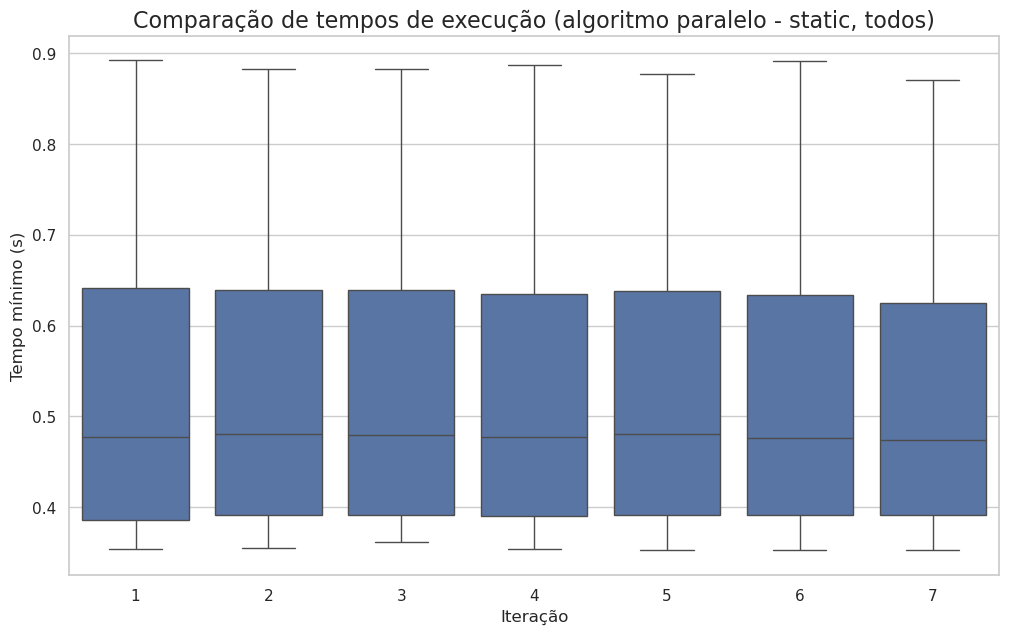

In [79]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="tempo_min")

plt.title("Comparação de tempos de execução (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo mínimo (s)", fontsize=12)
plt.show()

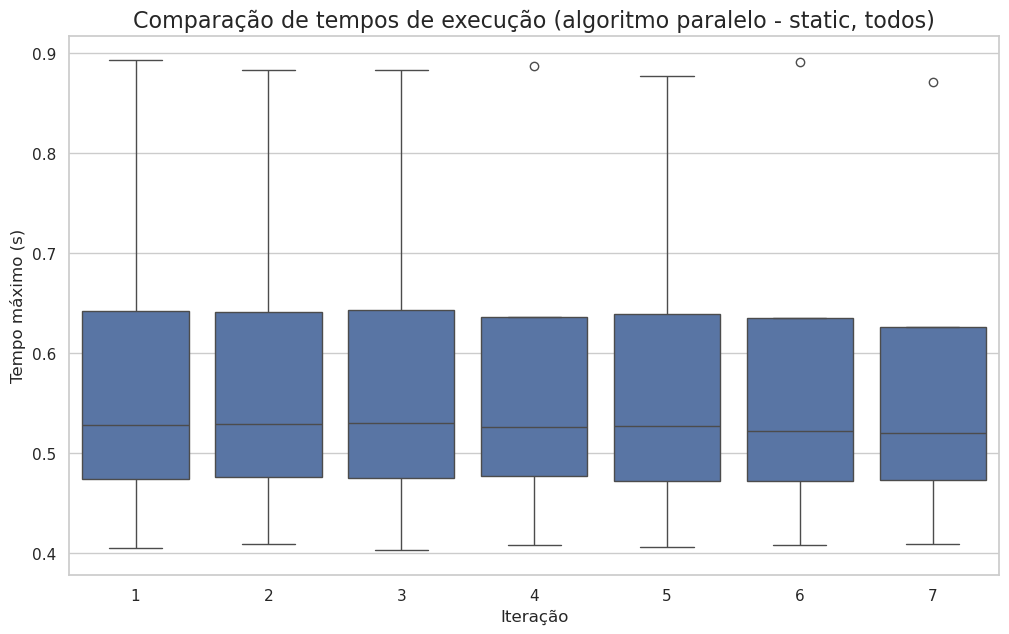

In [80]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="tempo_max")

plt.title("Comparação de tempos de execução (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo máximo (s)", fontsize=12)
plt.show()

##### Fator de balanceamento de carga (Fab)

In [81]:
print("Fab")
print("Média:", mpi_df["Fab"].mean())
print("Desvio padrão:", mpi_df["Fab"].std())
print("Valor mínimo:", mpi_df["Fab"].min())
print("Valor máximo:", mpi_df["Fab"].max())

Fab
Média: 1.0346606785714285
Desvio padrão: 0.05592962289908271
Valor mínimo: 1.000107
Valor máximo: 1.133114


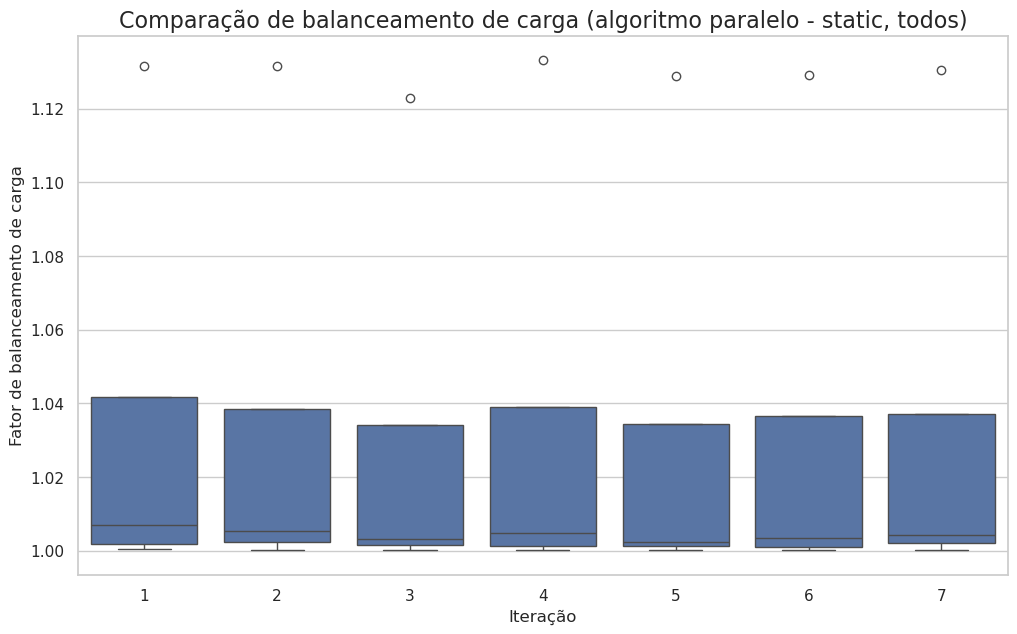

In [82]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="Fab")

plt.title("Comparação de balanceamento de carga (algoritmo paralelo - static, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de balanceamento de carga", fontsize=12)
plt.show()

##### *Speed-up*

In [83]:
print("Speed-up (com tempo mínimo)")
print("Média:", mpi_df["speed_up_min"].mean())
print("Desvio padrão:", mpi_df["speed_up_min"].std())
print("Valor mínimo:", mpi_df["speed_up_min"].min())
print("Valor máximo:", mpi_df["speed_up_min"].max())

print("\n\nSpeed-up (com tempo máximo)")
print("Média:", mpi_df["speed_up_max"].mean())
print("Desvio padrão:", mpi_df["speed_up_max"].std())
print("Valor mínimo:", mpi_df["speed_up_max"].min())
print("Valor máximo:", mpi_df["speed_up_max"].max())

Speed-up (com tempo mínimo)
Média: 17.565695
Desvio padrão: 6.79416
Valor mínimo: 6.53272
Valor máximo: 27.526236


Speed-up (com tempo máximo)
Média: 15.773402
Desvio padrão: 5.347153
Valor mínimo: 6.5313272
Valor máximo: 24.041538


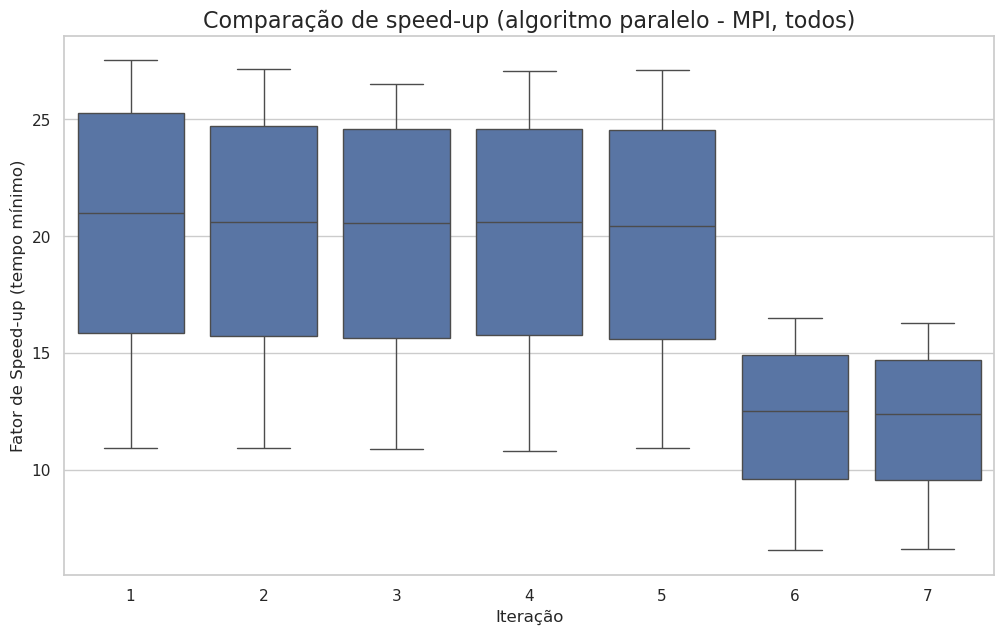

In [84]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="speed_up_min")

plt.title("Comparação de speed-up (algoritmo paralelo - MPI, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up (tempo mínimo)", fontsize=12)
plt.show()

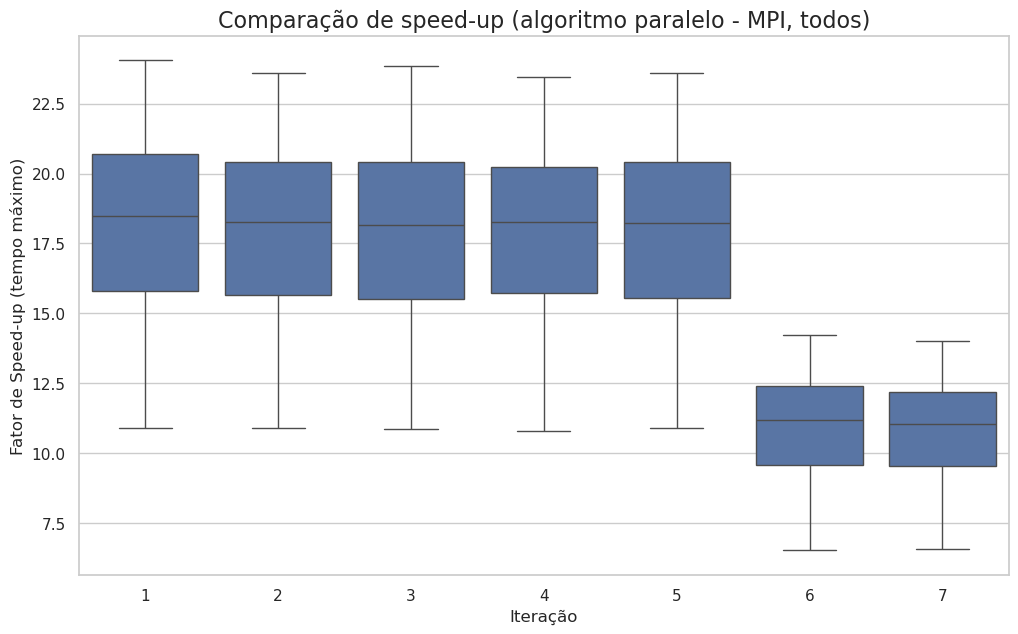

In [85]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="speed_up_max")

plt.title("Comparação de speed-up (algoritmo paralelo - MPI, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Fator de Speed-up (tempo máximo)", fontsize=12)
plt.show()

##### Eficiência

In [86]:
print("Eficiência (tempo mínimo)")
print("Média:", mpi_df["eficiencia_min"].mean())
print("Desvio padrão:", mpi_df["eficiencia_min"].std())
print("Valor mínimo:", mpi_df["eficiencia_min"].min())
print("Valor máximo:", mpi_df["eficiencia_min"].max())

print("\n\nEficiência (tempo máximo)")
print("Média:", mpi_df["eficiencia_max"].mean())
print("Desvio padrão:", mpi_df["eficiencia_max"].std())
print("Valor mínimo:", mpi_df["eficiencia_max"].min())
print("Valor máximo:", mpi_df["eficiencia_max"].max())

Eficiência (tempo mínimo)
Média: 3.205863790852683
Desvio padrão: 1.4554633727101047
Valor mínimo: 1.0162498950958252
Valor máximo: 5.4604034423828125


Eficiência (tempo máximo)
Média: 3.0868566376822337
Desvio padrão: 1.5864811121497666
Valor mínimo: 0.724134624004364
Valor máximo: 5.458882808685303


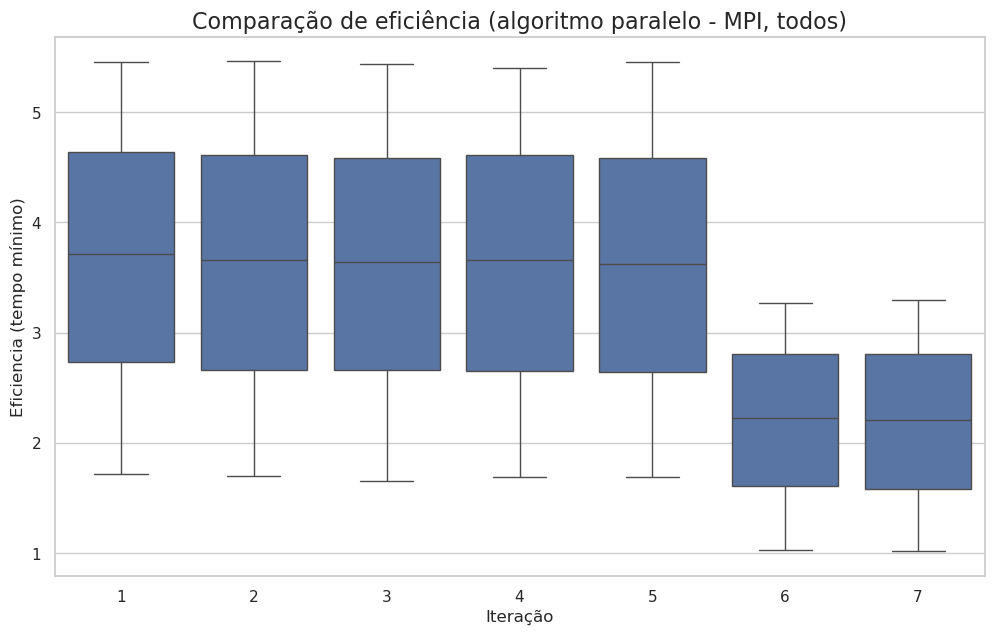

In [87]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="eficiencia_min")

plt.title("Comparação de eficiência (algoritmo paralelo - MPI, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo mínimo)", fontsize=12)
plt.show()

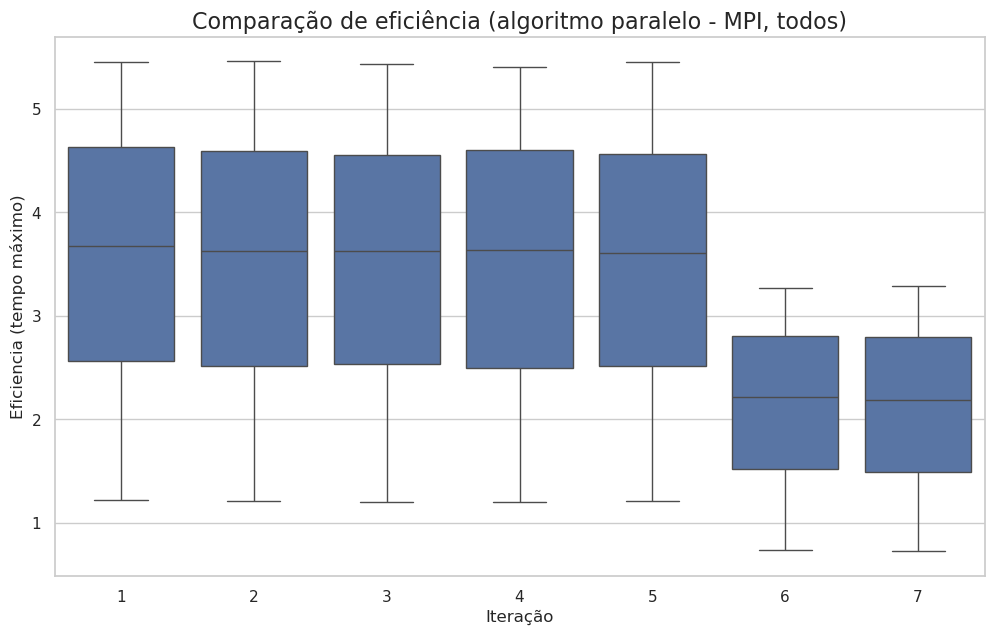

In [88]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=mpi_df, x="interacao", y="eficiencia_max")

plt.title("Comparação de eficiência (algoritmo paralelo - MPI, todos)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Eficiencia (tempo máximo)", fontsize=12)
plt.show()

### Teste de corretude

#### Consistência

Os testes foram realizados com 5 imagens de *label* de artérias coronárias retiradas do trabalho  [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052). Mais precisamente, as imagens: 120, 205, 510, 650, e 980.

#### Utilizando o terminal Linux (Bash)

Utilizando o comando `diff` com a *flag* `-q` e os hiperparâmetros `output_sequential.txt` e `output_openMP.txt` foi feita uma comparação entre os dois aquivos de saída.
<br>
O utilitário `diff` mostra quais são as diferenças, mas com a *flag* -q (*quiet*/*brief*), ele apenas dá um resumo se os arquivos são diferentes ou não.
<br>
Nesse teste, o `diff` não mostrou saída nenhuma. Isso é uma indicação de que os arquivo são idênticos.
<br>
É possível reproduzir o resultado no terminal Linux (Bash) utilizando o trecho de código abaixo.

```sh
diff -q output_sequential.txt output_MPI.txt
```

#### Comparação com algoritmo implementado em linguagem Python

O algoritmo de *bounding box* implementando nesse trabalho foi validado em contraste com o algoritmo Python abaixo.
```python
def get_crop(pre_label, img, label,enhance):
    x, y, z = np.where(pre_label == 1)
    img_shape = img.shape

    x_max = (x.max() + 5) if (x.max() + 5) <= img_shape[0] else img_shape[0]
    y_max = (y.max() + 5) if (y.max() + 5) <= img_shape[1] else img_shape[1]
    z_max = (z.max() + 5) if (z.max() + 5) <= img_shape[2] else img_shape[2]

    x_min = x.min() - 5 if (x.min() - 5) >= 0 else 0
    y_min = y.min() - 5 if (y.min() - 5) >= 0 else 0
    z_min = z.min() - 5 if (z.min() - 5) >= 0 else 0

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    img_crop = img[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    label_crop = label[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    enhance_crop = enhance[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    return img_crop, label_crop, enhance_crop, loc_min, loc_max
```

Para se adequar ao problema atual, será feita a seguinte modificação no código.

```python
def get_crop(label):
    x, y, z = np.where(label == 1)
    label_shape = label.shape

    x_max = min(x.max() + 5, label_shape[0])
    y_max = min(y.max() + 5, label_shape[1])
    z_max = min(z.max() + 5, label_shape[2])

    x_min = max(x.min() - 5, 0)
    y_min = max(y.min() - 5, 0)
    z_min = max(z.min() - 5, 0)

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    label_crop = label[loc_min[0]:loc_max[0], 
                       loc_min[1]:loc_max[1], 
                       loc_min[2]:loc_max[2]]

    return label_crop
```

O algoritmo acima for retirado do artigo [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052).
A saída do trecho acima não foi salvo em arquivo.
<br>
A implementação do teste está apresentada abaixo.

##### Execução do teste

###### Importando pacotes

In [89]:
import nibabel as nib

###### Funções

In [90]:
def get_crop(label):
    x, y, z = np.where(label == 1)
    label_shape = label.shape

    x_max = min(x.max() + 5, label_shape[0])
    y_max = min(y.max() + 5, label_shape[1])
    z_max = min(z.max() + 5, label_shape[2])

    x_min = max(x.min() - 5, 0)
    y_min = max(y.min() - 5, 0)
    z_min = max(z.min() - 5, 0)

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    label_crop = label[loc_min[0]:loc_max[0], 
                       loc_min[1]:loc_max[1], 
                       loc_min[2]:loc_max[2]]

    return label_crop

def load_tensor_from_text_file(file_path: str) -> np.ndarray[float]:
    content: str

    with open(file_path, "r") as file_descriptor:
        content = file_descriptor.read()

    raw_data: str = content.replace("---- ---- ----", " ").replace("\n", " ")
    temp_tensor: nd.ndarray[float] = np.fromstring(raw_data, sep="\t")

    slices_string: str = content.strip().split("---- ---- ----")
    first_slice_lines: str = slices_string[0].strip().split("\n")

    x_axis: int = len(first_slice_lines)
    y_axis: int = len([val for val in first_slice_lines[0].split("\t") if val.strip()])
    total_elements: int = temp_tensor.size
    z_axis: int = total_elements // (x_axis * y_axis)

    if total_elements != (z_axis * x_axis * y_axis):
        print(f"Aviso: Dados desalinhados. Total: {total_elements}, Esperado: {z_axis * x_axis * y_axis}")
        temp_tensor = temp_tensor[:z_axis * x_axis * y_axis]

    tensor: np.ndarray[float] = temp_tensor.reshape((z_axis, x_axis, y_axis))

    return tensor.transpose(1, 2, 0)

###### *Bounding box* próprio

In [91]:
file_path: str = "../input3.txt"

with open(file_path, "r") as file_descriptor:
    print("Dimensões da imagem original:")
    print("- Linhas:", file_descriptor.readline().strip())
    print("- Colunas:", file_descriptor.readline().strip())
    print("- Slices:", file_descriptor.readline().strip())

Dimensões da imagem original:
- Linhas: 512
- Colunas: 512
- Slices: 275


In [92]:
file_path: str = "../output_sequential.txt"
cropped_tensor: np.ndarray = load_tensor_from_text_file(file_path)

print("Tamanho da imagem cortada:", cropped_tensor.shape)

Tamanho da imagem cortada: (314, 249, 182)


###### *Bounding box* de validação

In [93]:
image_path: str = "../images/120.label.nii.gz"
tensor: np.ndarray = nib.load(image_path).get_fdata()
cropped_tensor_validation: np.ndarray = get_crop(tensor)

print("Dimensões da imagem original:", tensor.shape)
print("Dimensões da imagem cortada:", cropped_tensor_validation.shape)

Dimensões da imagem original: (512, 512, 275)
Dimensões da imagem cortada: (313, 248, 181)


Como é possível notar acima, os arrays possuem dimensões diferentes. A diferença é de 1 elemento em cada dimensão.
<br>
A seguir, será testado se, mesmo com essa diferença nas dimensões, a subtração entre os dois array gera um terceiro array nulo ou com poucos valores unitários).

In [94]:
cropped_tensor = cropped_tensor[:313, :248, :181]

In [95]:
difference_array: np.ndarray[float] = cropped_tensor_validation - cropped_tensor

print("Maior valor da subtração:", np.max(difference_array))
print("Quantidade de valores não nulos:", np.count_nonzero(difference_array == 1.0))

Maior valor da subtração: 0.0
Quantidade de valores não nulos: 0


##### Execução do teste com o mesmo arquivo de entrada (`input3.txt`).

In [96]:
file_path: str = "../input3.txt"
tensor: np.ndarray[float] = np.loadtxt(file_path, delimiter=" ", skiprows=3, dtype=float).reshape((512, 512, 275))

print("Dimensões da imagem original:", tensor.shape)

cropped_tensor_validation: np.ndarray[float] = get_crop(tensor)

print("Dimensões da imagem cortada:", cropped_tensor_validation.shape)

Dimensões da imagem original: (512, 512, 275)
Dimensões da imagem cortada: (313, 248, 181)


In [204]:
difference_array = cropped_tensor_validation - cropped_tensor[:313, :248, :181]

print("Maior valor da subtração:", np.max(difference_array))
print("Quantidade de valores não nulos:", np.count_nonzero(difference_array == 1.0))

Maior valor da subtração: 0.0
Quantidade de valores não nulos: 0


### Melhor resultado (Fab)
Com MPI, o número de processos que gerou o melhor resultado de balanceamento de carga foi **16** com `1,133114` **(113,31%)**.
<br>
Resultado da iteração 4.
<br>

### Pior resultado (Fab)
Com MPI, o número de processos que gerou o pior resultado de balanceamento de carga foi **2** com `1,000107` **(100,00%)**.
<br>
Resultado da iteração 6.

### Melhor resultado (Tempo de execução)
Com MPI, o número de processos que gerou o menor tempo de execução foi **16**, onde:
- Utilizando o maior tempo: `0,352501`(s);
- Utilizando o menor tempo:	`0,493787`(s).
<br>
Resultado da iteração 6.
<br>

### Pior resultado (Tempo de execução)
Com MPI, o número de processos que gerou o  maior tempo de execução foi **2**, onde:
- Utilizando o maior tempo: `0,891998`(s);
- Utilizando o menor tempo:	`0,892713`(s).
<br>
Resultado da iteração 1.

### Melhor resultado (Speed-up)
Com MPI, o número de processos que gerou o melhor *Speed-up* foi **16**, onde:
- Utilizando o maior tempo: `19,583529`;
- Utilizando o menor tempo:	`27,526236`.
<br>
Resultado da iteração 1.
<br>

### Pior resultado (Speed-up)
Com MPI, o número de processos que gerou o melhor *Speed-up* foi **2**, onde:
- Utilizando o maior tempo: `6,531327`;
- Utilizando o menor tempo:	`6,532720`.
<br>
Resultado da iteração 6.

### Melhor resultado (Eficiência)
Com MPI, o número de processos que gerou a melhor eficiência foi **2**, onde:
- Utilizando o maior tempo: `5,458883` ***(545,88%)***;
- Utilizando o menor tempo: `5,460403` ***(546,04%)***.
<br>
Resultado da iteração 1.
<br>

### Pior resultado (Eficiência)
Com MPI, o número de processos que gerou a pior eficiência foi **16**, onde:
- Utilizando o maior tempo: `0,724135` ***(72,41%)***;
- Utilizando o menor tempo:	`1,016250` ***(101,63%)***.
<br>
Resultado da iteração 7.